In [1]:
import pandas as pd
import seaborn as sns
from matplotlib import pyplot as plt
from matplotlib.ticker import FuncFormatter
import numpy as np
from sklearn.preprocessing import StandardScaler, MinMaxScaler, RobustScaler

import warnings

warnings.filterwarnings("ignore")


In [2]:
df = pd.read_csv('../data/urban_lifestyle_impact_dataset.csv')
df.sample(10)

,daily_travel_time,vehicle_ownership,location_type,nearby_industries,green_space_access,home_air_quality,work_location_type,smoker_in_household,noise_pollution_level,use_of_air_purifiers,awareness_level,years_in_location,pollution_exposure_score,risk_category
8871,46.6,Public Only,Urban,2.0,NaN,70.0,Factory,False,68.1,False,Low,29.0,62.30,Medium
4867,44.3,NaN,Semi-Urban,NaN,NaN,41.8,Factory,False,40.6,False,Low,26.0,52.46,Medium
3828,68.6,Car,Urban,5.0,Moderate,71.2,Fieldwork,False,34.5,False,High,5.0,64.61,Medium
3982,108.0,Public Only,Urban,3.0,Low,77.0,Remote,False,41.4,False,Medium,NaN,57.04,Medium
8564,0.0,Car,Rural,4.0,Moderate,60.3,Factory,False,20.1,False,High,34.0,46.02,Medium
824,NaN,Public Only,Semi-Urban,1.0,Low,78.4,Remote,False,56.1,True,High,31.0,29.69,Low
9115,NaN,Two-wheeler,Urban,2.0,Moderate,58.2,Fieldwork,True,48.4,False,Low,24.0,53.70,Medium
2908,36.0,NaN,Semi-Urban,3.0,High,58.7,Factory,False,62.1,True,Medium,9.0,39.09,Medium
7937,93.4,NaN,Semi-Urban,3.0,Moderate,59.8,Fieldwork,True,71.9,False,High,32.0,60.48,Medium
8200,0.0,NaN,Semi-Urban,4.0,Moderate,82.9,Fieldwork,False,9.1,False,Low,36.0,44.60,Medium


In [3]:
# Print column and type
for col, dtype in df.dtypes.items():
    mem_usage = df[col].memory_usage(deep=True)
    print(f"{col} - {dtype} ({mem_usage:,} bytes)")

daily_travel_time - float64 (80,132 bytes)
vehicle_ownership - object (493,468 bytes)
location_type - object (555,602 bytes)
nearby_industries - float64 (80,132 bytes)
green_space_access - object (534,552 bytes)
home_air_quality - float64 (80,132 bytes)
work_location_type - object (544,487 bytes)
smoker_in_household - bool (10,132 bytes)
noise_pollution_level - float64 (80,132 bytes)
use_of_air_purifiers - bool (10,132 bytes)
awareness_level - object (513,343 bytes)
years_in_location - float64 (80,132 bytes)
pollution_exposure_score - float64 (80,132 bytes)
risk_category - object (546,108 bytes)


In [4]:
# Print unique values for object columns
for col in df.select_dtypes(include="object").columns:
    unique_vals = df[col].dropna().unique()
    print(f"Column: {col}, Unique Values ({len(unique_vals)}): {unique_vals[:10]}{'...' if len(unique_vals) > 10 else ''}")

Column: vehicle_ownership, Unique Values (3): ['Public Only' 'Car' 'Two-wheeler']
Column: location_type, Unique Values (3): ['Semi-Urban' 'Urban' 'Rural']
Column: green_space_access, Unique Values (3): ['Moderate' 'High' 'Low']
Column: work_location_type, Unique Values (4): ['Factory' 'Remote' 'Office' 'Fieldwork']
Column: awareness_level, Unique Values (3): ['Low' 'Medium' 'High']
Column: risk_category, Unique Values (3): ['Medium' 'High' 'Low']


In [5]:
# Print number of rows and columns
print(f"Number of rows: {df.shape[0]}")
print(f"Number of columns: {df.shape[1]}")
print(f"Number of duplicate rows: {df.duplicated().sum()}")

Number of rows: 10000
Number of columns: 14
Number of duplicate rows: 0


In [6]:
# Print percentage of missing values per column
for col in df.columns:
    missing_percentage = df[col].isnull().mean() * 100
    print(f"{col}: {missing_percentage:.2f}% missing values")

daily_travel_time: 11.24% missing values
vehicle_ownership: 31.64% missing values
location_type: 0.00% missing values
nearby_industries: 7.95% missing values
green_space_access: 5.60% missing values
home_air_quality: 0.00% missing values
work_location_type: 6.53% missing values
smoker_in_household: 0.00% missing values
noise_pollution_level: 0.00% missing values
use_of_air_purifiers: 0.00% missing values
awareness_level: 10.15% missing values
years_in_location: 5.20% missing values
pollution_exposure_score: 0.00% missing values
risk_category: 0.00% missing values


In [7]:
numerical_cols = df.select_dtypes(include="number").columns
categorical_cols = df.select_dtypes(include="object").columns

In [8]:
def plot_categorical_bar(df, col, ax=None, top_n=10):
    if col not in df.columns:
        if ax is None:
            print(f"Warning: Column '{col}' not found")
        return

    s = df[col]
    total = len(s)
    missing_pct = s.isna().mean() * 100

    # Get top values
    counts = s.value_counts(dropna=True).head(top_n)
    counts = (counts / total) * 100

    missing = s.isna().sum()
    if missing > 0:
        counts["<MISSING>"] = (missing / total) * 100

    plot_df = counts.reset_index()
    plot_df.columns = [col, "Percentage"]

    # Colors (missing = red)
    color_map = {
        v: ("red" if v == "<MISSING>" else "steelblue")
        for v in plot_df[col]
    }

    if ax is None:
        fig, ax = plt.subplots(figsize=(8, 4))

    sns.barplot(
        data=plot_df,
        y=col,
        x="Percentage",
        hue=col,
        palette=color_map,
        orient="h",
        dodge=False,
        legend=False,
        ax=ax
    )

    ax.set_title(f"{col} (Missing: {missing_pct:.2f}%)")
    ax.set_xlabel("Percentage (%)")
    ax.set_ylabel(col)


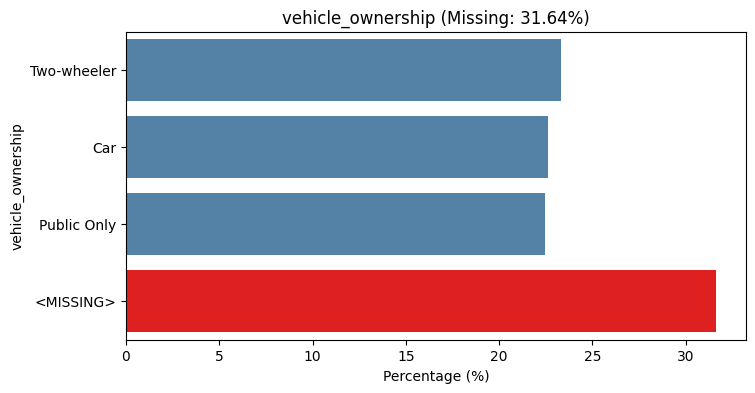

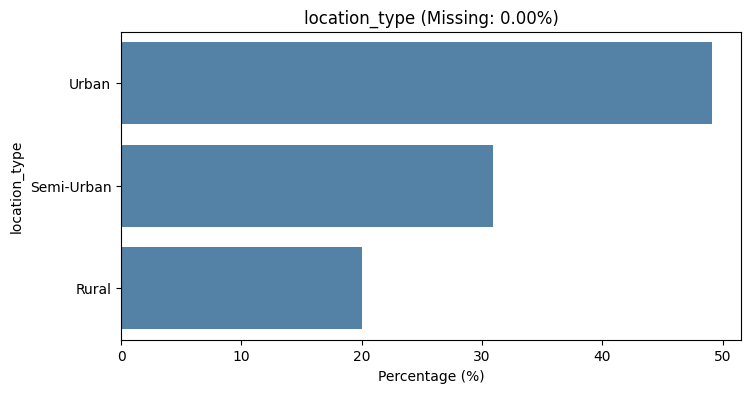

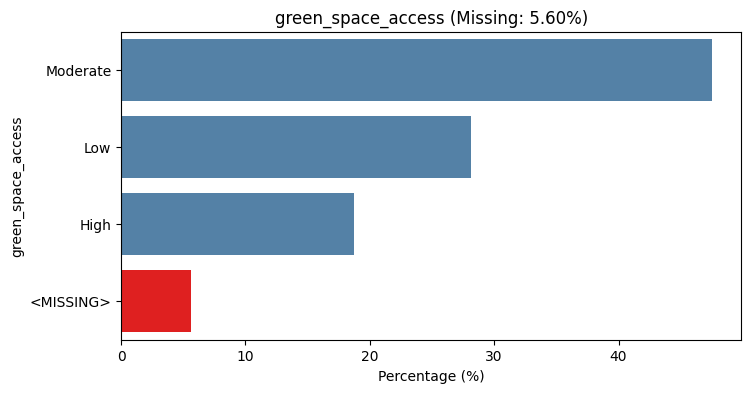

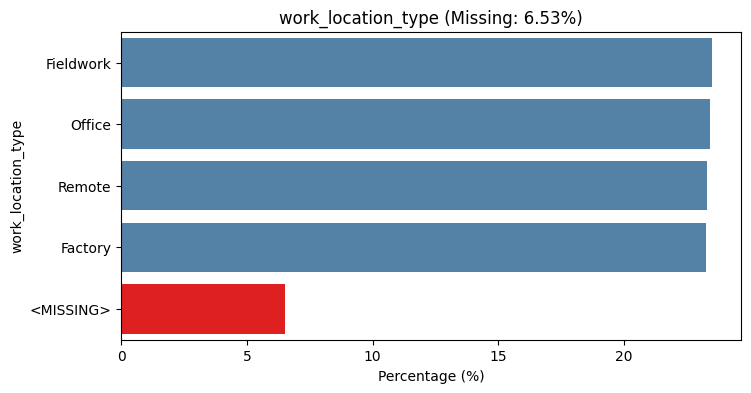

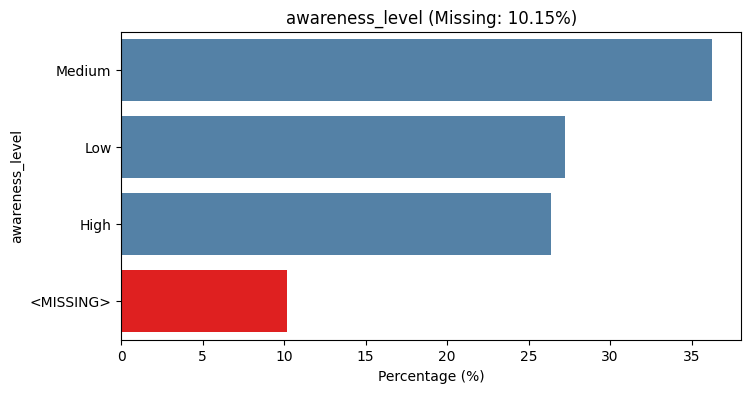

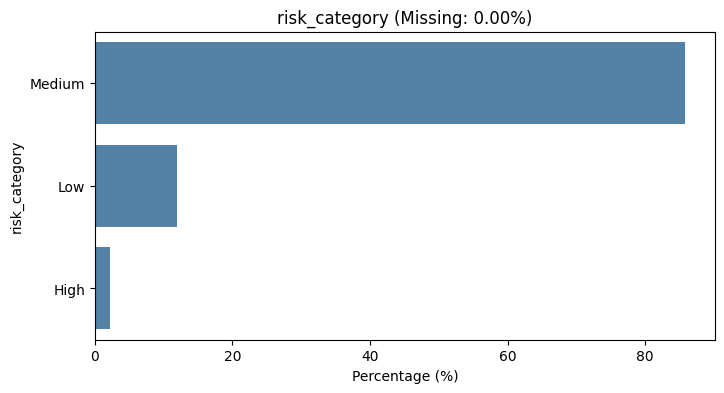

In [9]:
for col in categorical_cols:
    plot_categorical_bar(df, col)

In [10]:
# Print for each numeric column mean, median, std, min, max, quantiles
for col in df.select_dtypes(include="number"):
    print(f"{col}:")
    print(f"  Mean: {df[col].mean():,.2f}")
    print(f"  Median: {df[col].median():,.2f}")
    print(f"  Std: {df[col].std():,.2f}")
    print(f"  Min: {df[col].min():,.2f}")
    print(f"  Max: {df[col].max():,.2f}")
    print(f"  25th percentile: {df[col].quantile(0.25):,.2f}")
    print(f"  50th percentile: {df[col].quantile(0.50):,.2f}")
    print(f"  75th percentile: {df[col].quantile(0.75):,.2f}")

daily_travel_time:
  Mean: 45.15
  Median: 45.00
  Std: 19.89
  Min: 0.00
  Max: 123.50
  25th percentile: 31.60
  50th percentile: 45.00
  75th percentile: 58.52
nearby_industries:
  Mean: 1.99
  Median: 2.00
  Std: 1.42
  Min: 0.00
  Max: 10.00
  25th percentile: 1.00
  50th percentile: 2.00
  75th percentile: 3.00
home_air_quality:
  Mean: 60.11
  Median: 60.20
  Std: 15.16
  Min: 0.00
  Max: 100.00
  25th percentile: 49.80
  50th percentile: 60.20
  75th percentile: 70.50
noise_pollution_level:
  Mean: 50.12
  Median: 50.10
  Std: 20.05
  Min: 0.00
  Max: 100.00
  25th percentile: 36.80
  50th percentile: 50.10
  75th percentile: 63.60
years_in_location:
  Mean: 20.62
  Median: 21.00
  Std: 11.56
  Min: 1.00
  Max: 40.00
  25th percentile: 11.00
  50th percentile: 21.00
  75th percentile: 31.00
pollution_exposure_score:
  Mean: 44.09
  Median: 43.69
  Std: 12.07
  Min: 5.97
  Max: 100.00
  25th percentile: 35.52
  50th percentile: 43.69
  75th percentile: 52.01


In [11]:
def plot_numeric_hist(df, col, ax=None, bins=100):
    if col not in df.columns:
        if ax is None:
            print(f"Warning: Column '{col}' not found.")
        return
    
    s = df[col]
    data = s.dropna()
    total = len(s)
    missing_pct = s.isna().mean() * 100

    # create axis if standalone
    if ax is None:
        fig, ax = plt.subplots(figsize=(8, 4))

    # histogram
    sns.histplot(
        data,
        bins=bins,
        stat="count",
        ax=ax,
        color="steelblue",
        edgecolor=None
    )

    # stats
    if len(data) > 0:
        vmin = data.min()
        vmax = data.max()
        vmedian = data.median()
        vmean = data.mean()

        ax.axvline(vmin, color="red", linestyle="--", linewidth=1.4, label=f"Min={vmin:.2f}")
        ax.axvline(vmax, color="red", linestyle="--", linewidth=1.4, label=f"Max={vmax:.2f}")
        ax.axvline(vmedian, color="green", linestyle="--", linewidth=1.4, label=f"Median={vmedian:.2f}")
        ax.axvline(vmean, color="orange", linestyle="--", linewidth=1.4, label=f"Mean={vmean:.2f}")

    ax.set_title(f"{col} (Missing: {missing_pct:.2f}%)")
    ax.set_xlabel(col)
    ax.set_ylabel("Count")
    ax.legend()


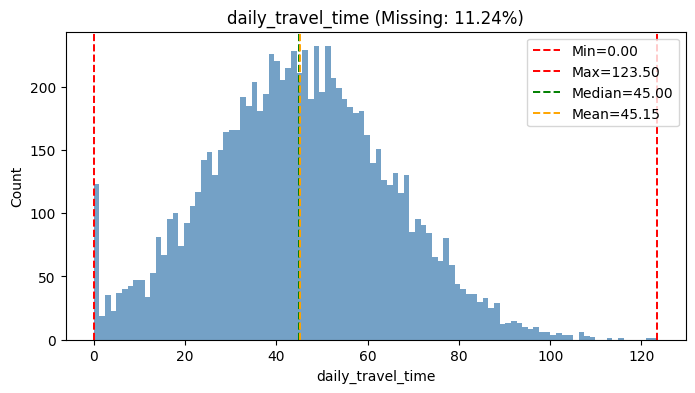

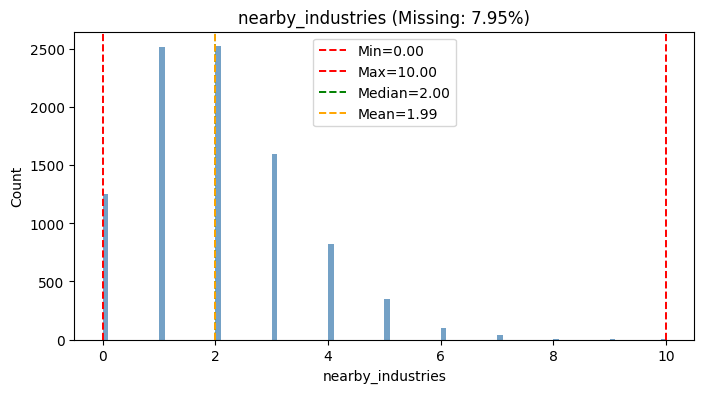

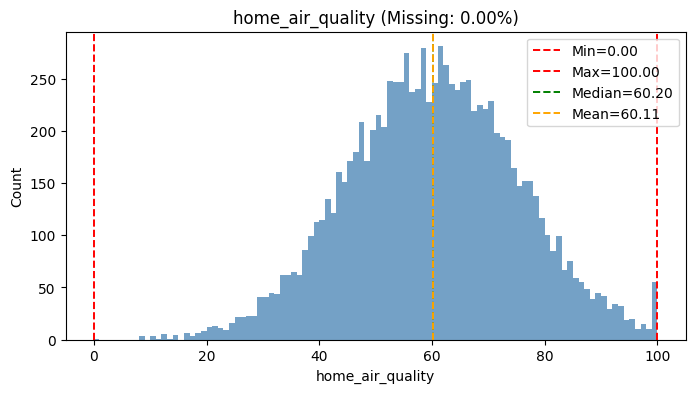

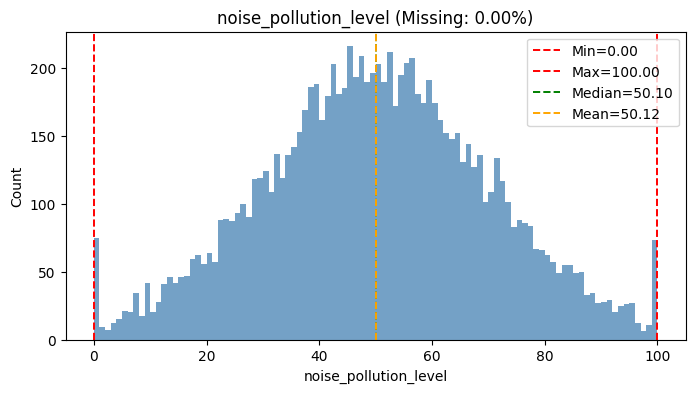

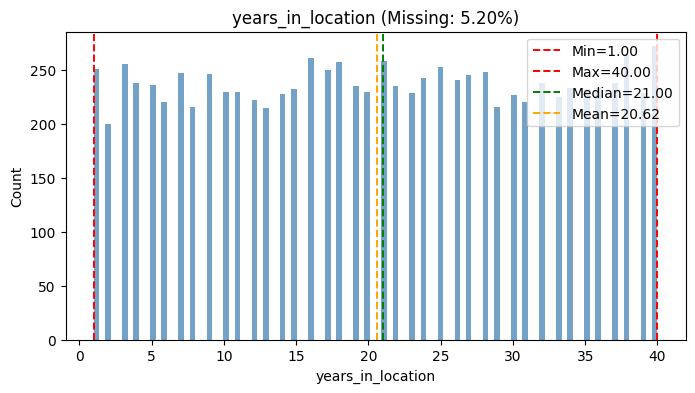

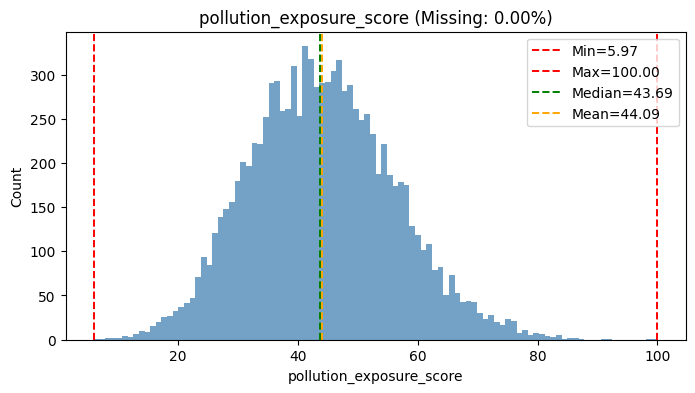

In [12]:
for col in numerical_cols:
    plot_numeric_hist(df, col)

Text(0.5, 1.0, 'Correlation Heatmap of Numeric Columns')

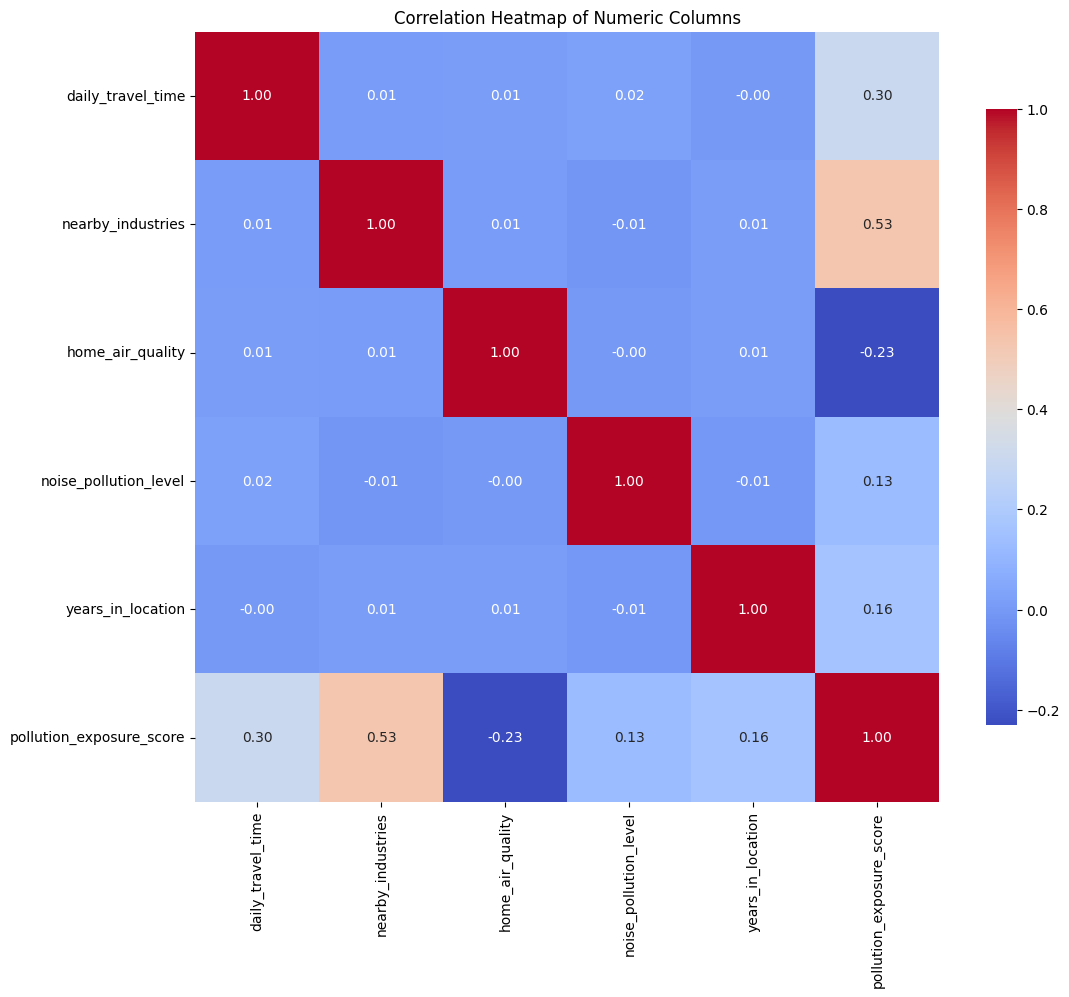

In [14]:
# Plot correlation heatmap of numeric columns
plt.figure(figsize=(12, 10))
corr = df[numerical_cols].corr()
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", cbar_kws={"shrink": .8})
plt.title("Correlation Heatmap of Numeric Columns")

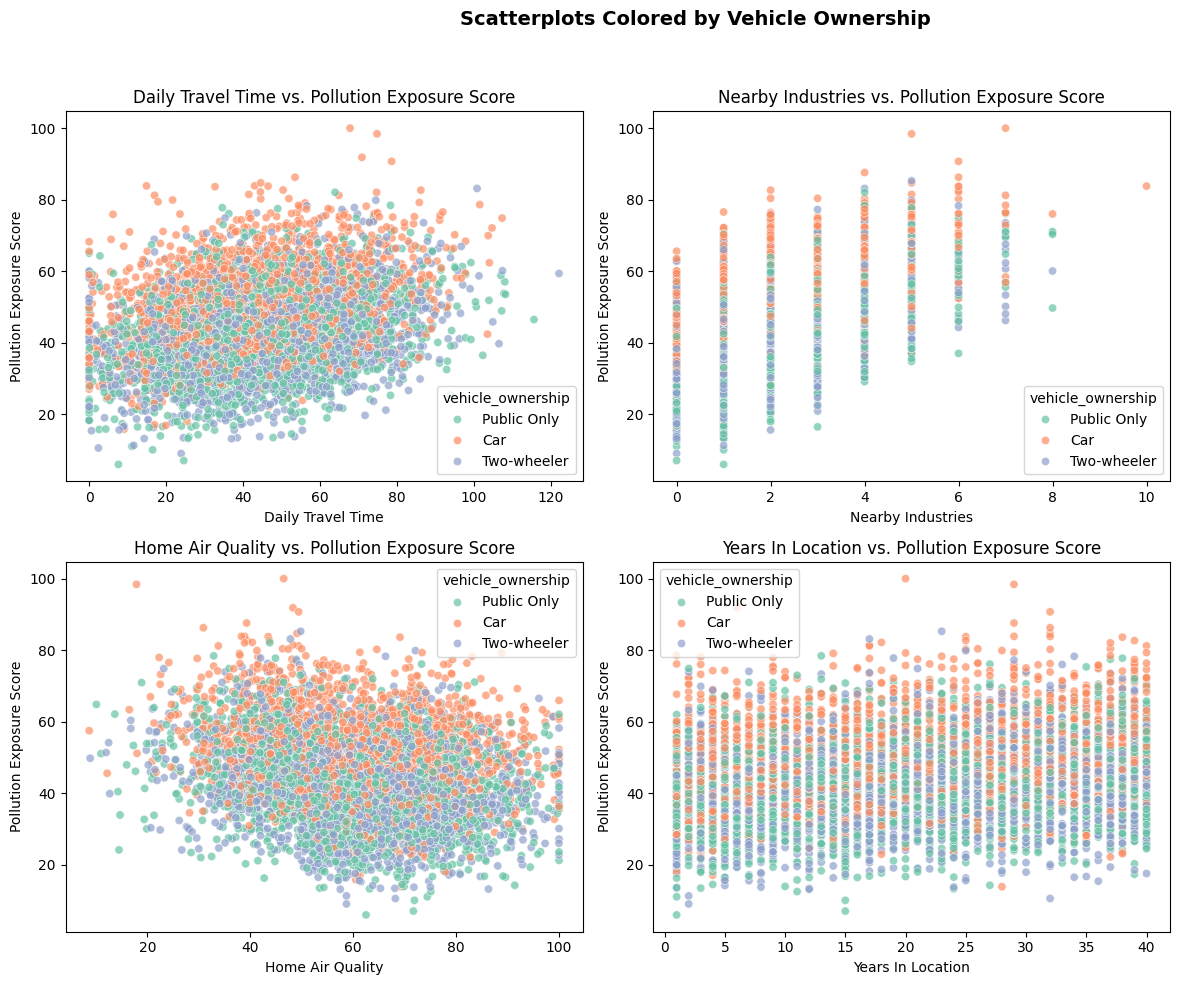

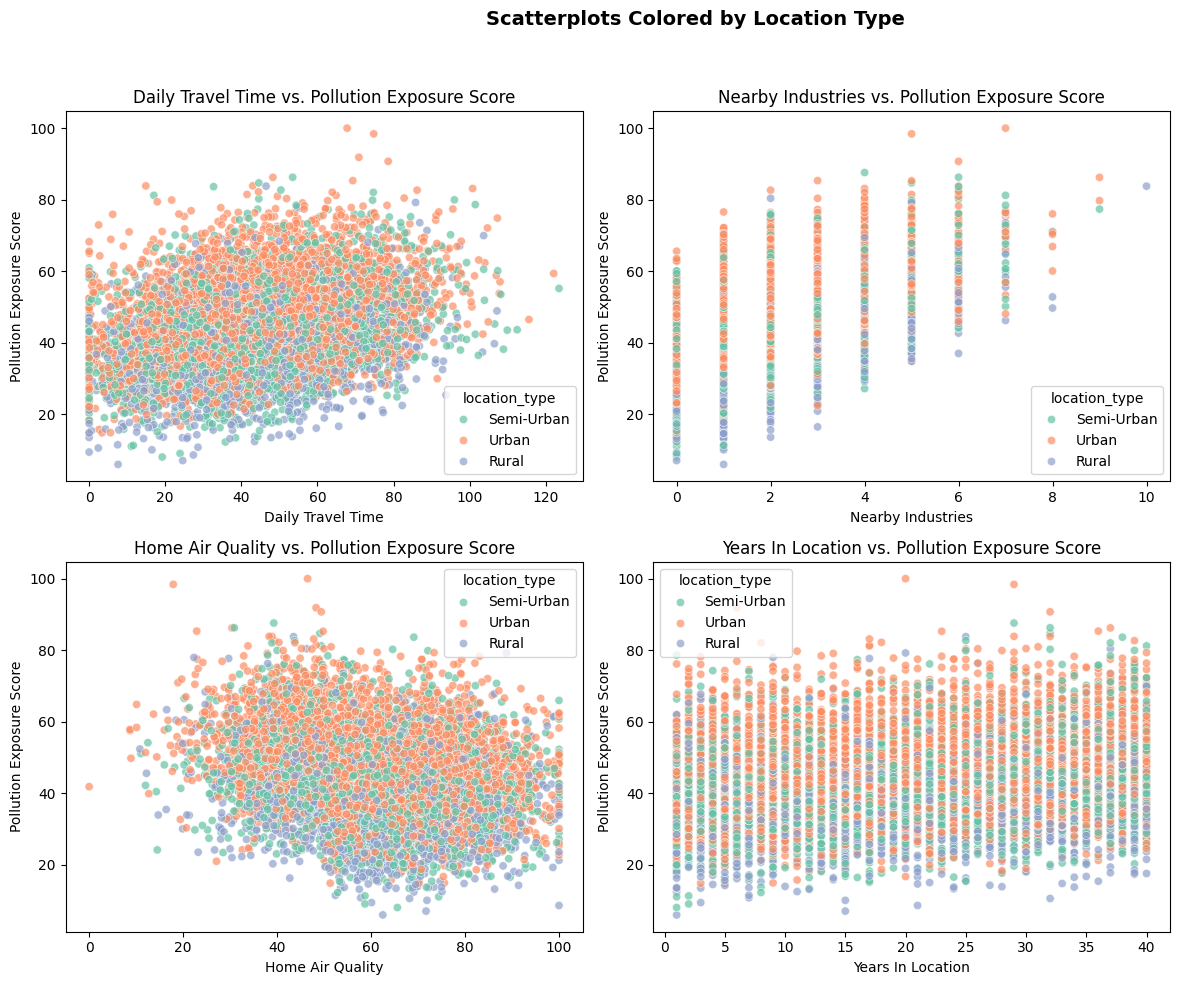

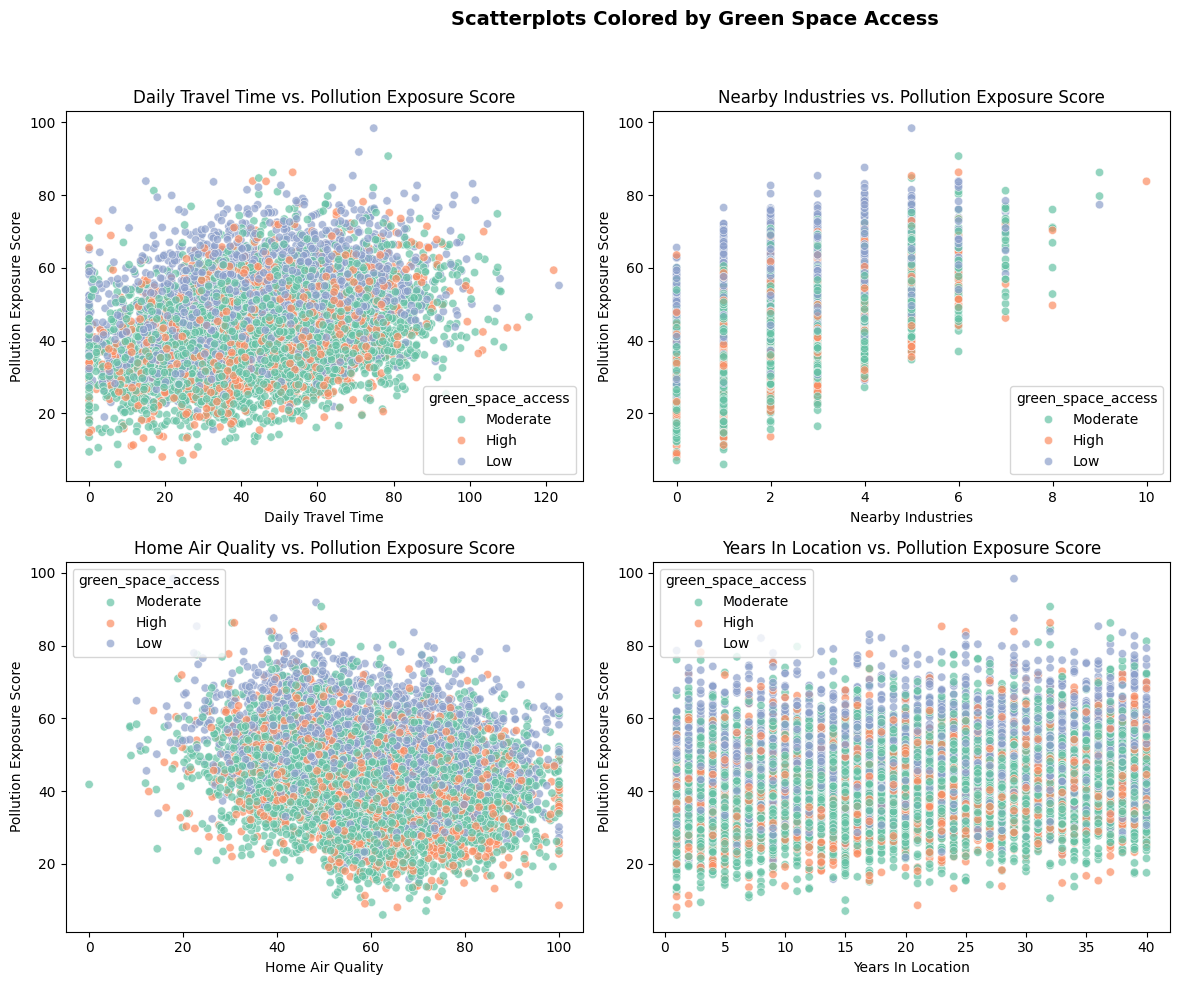

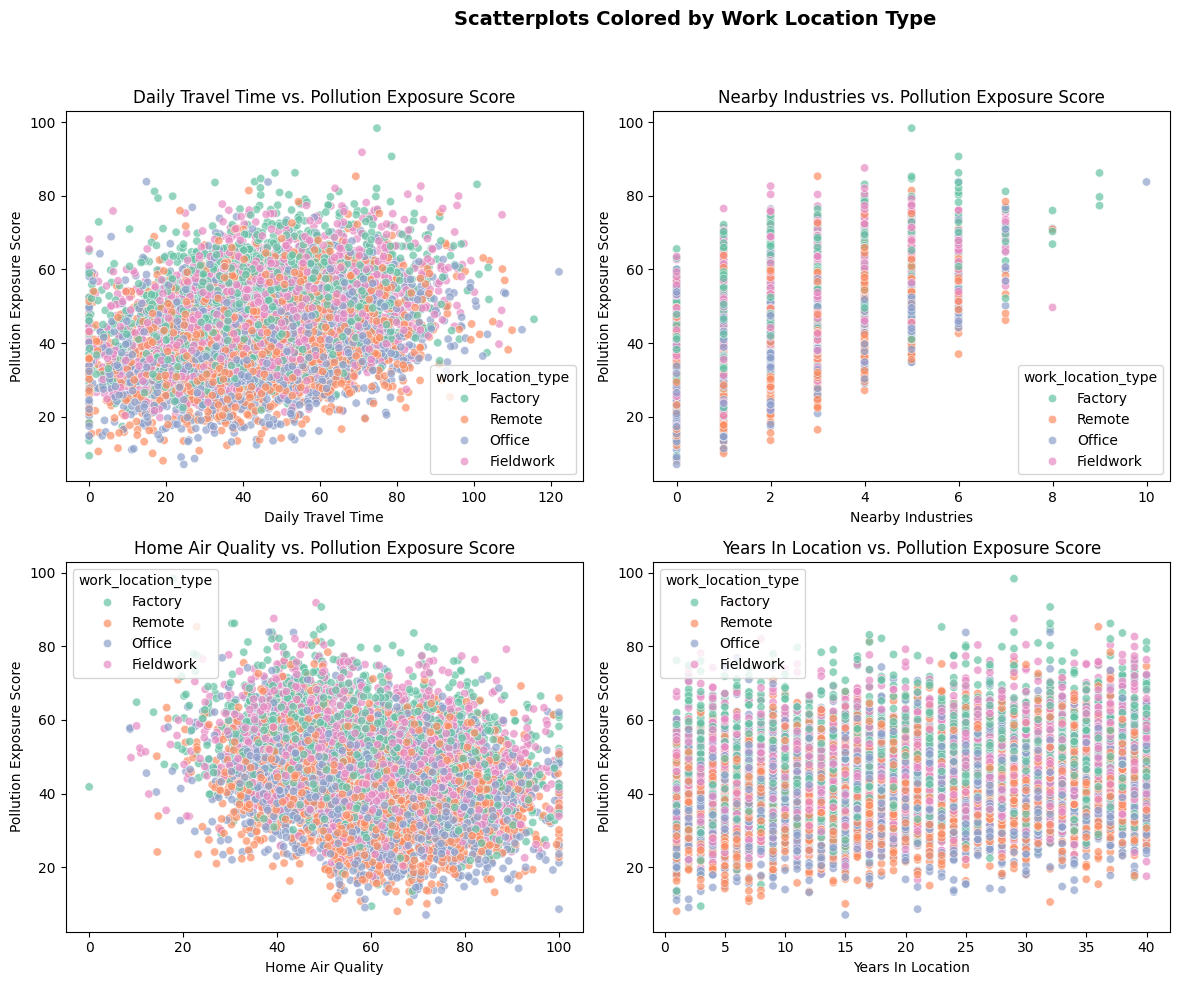

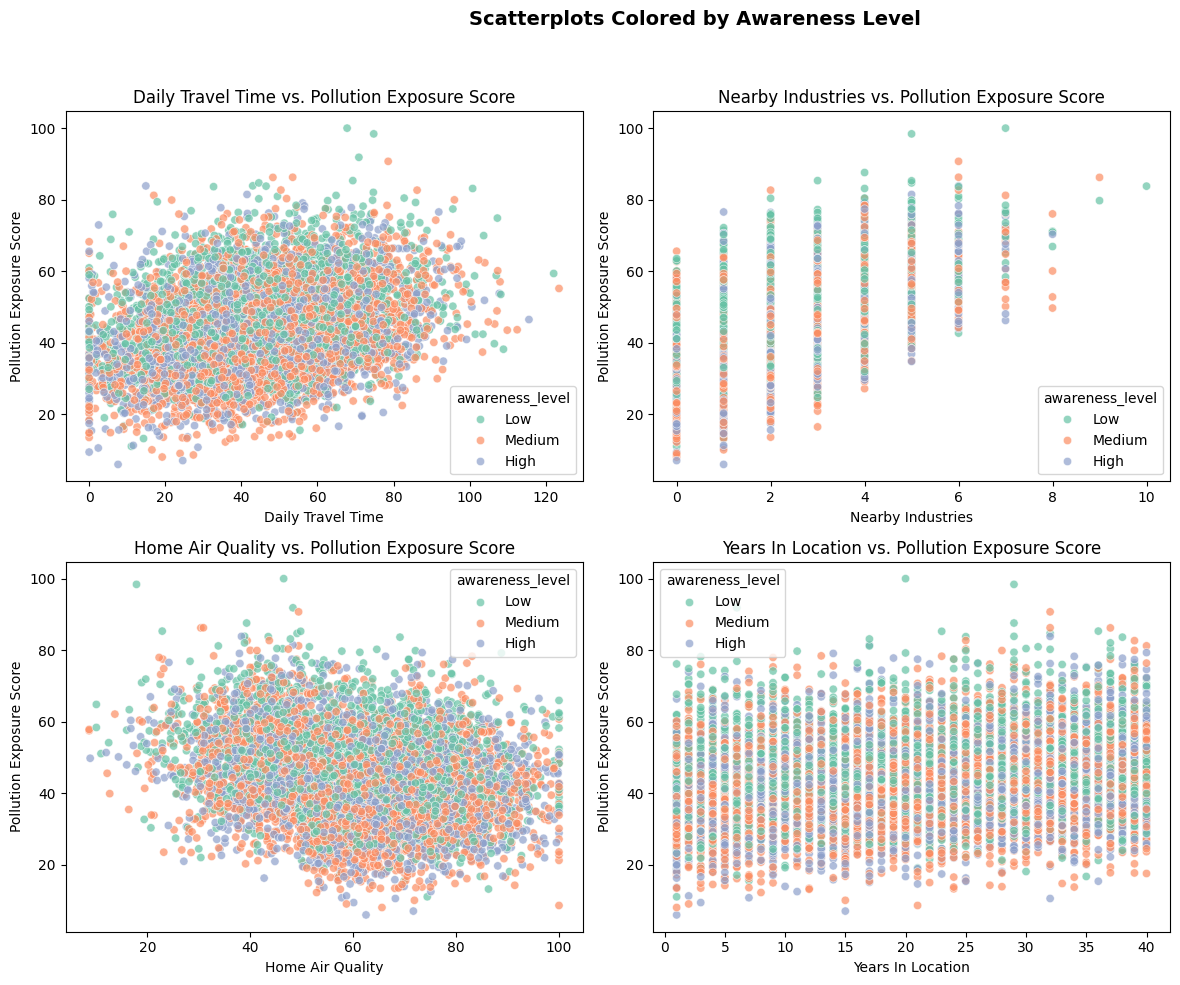

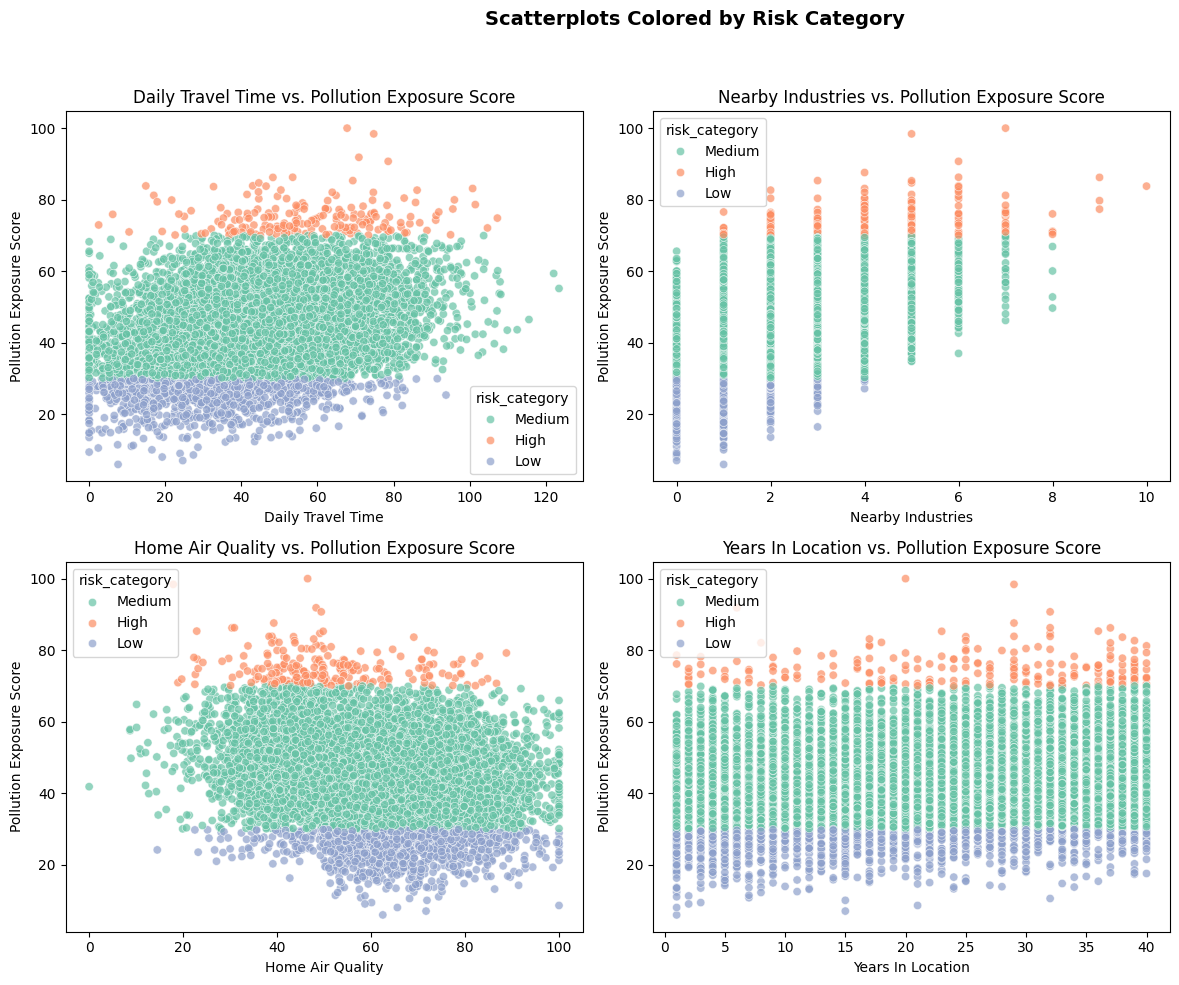

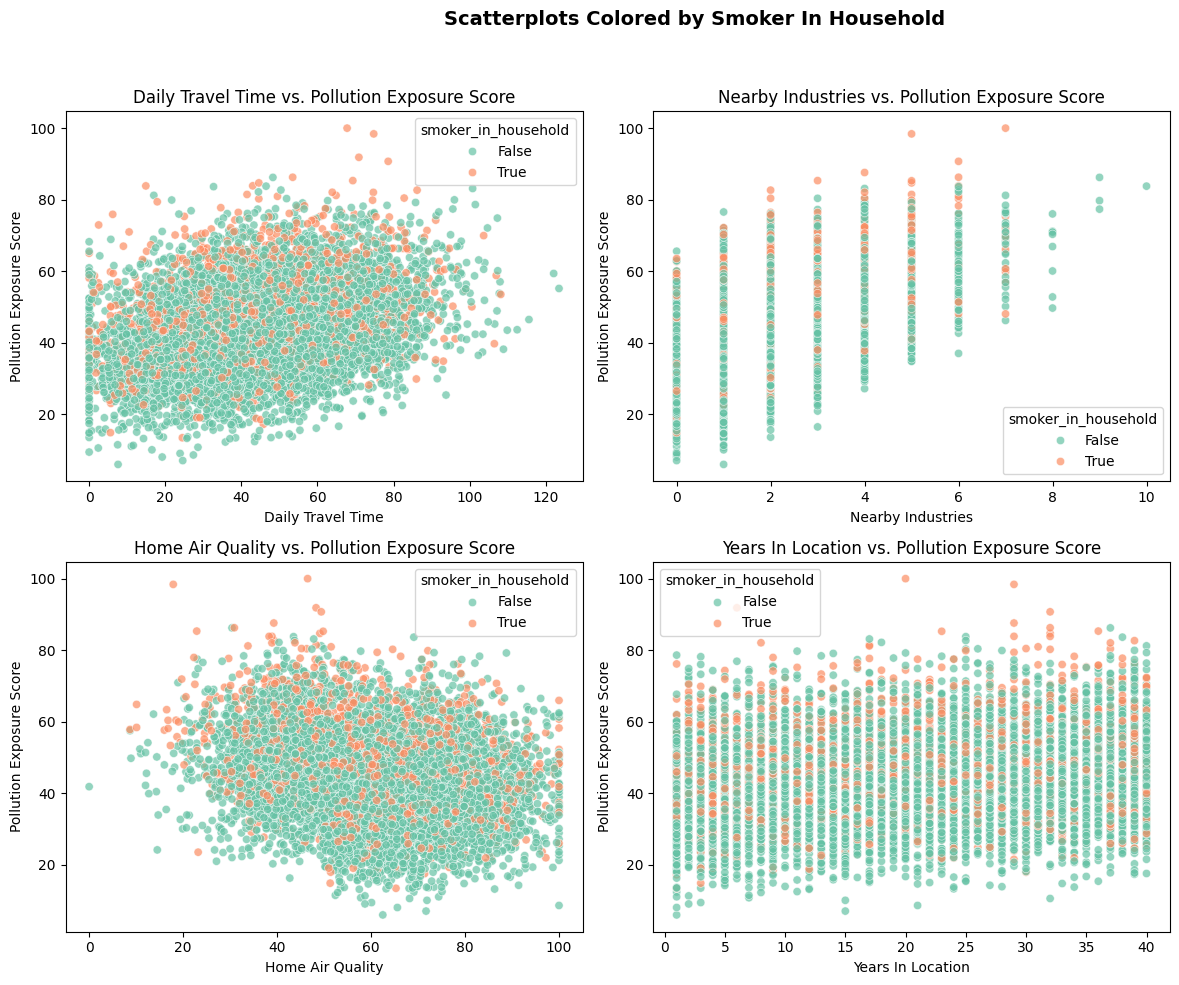

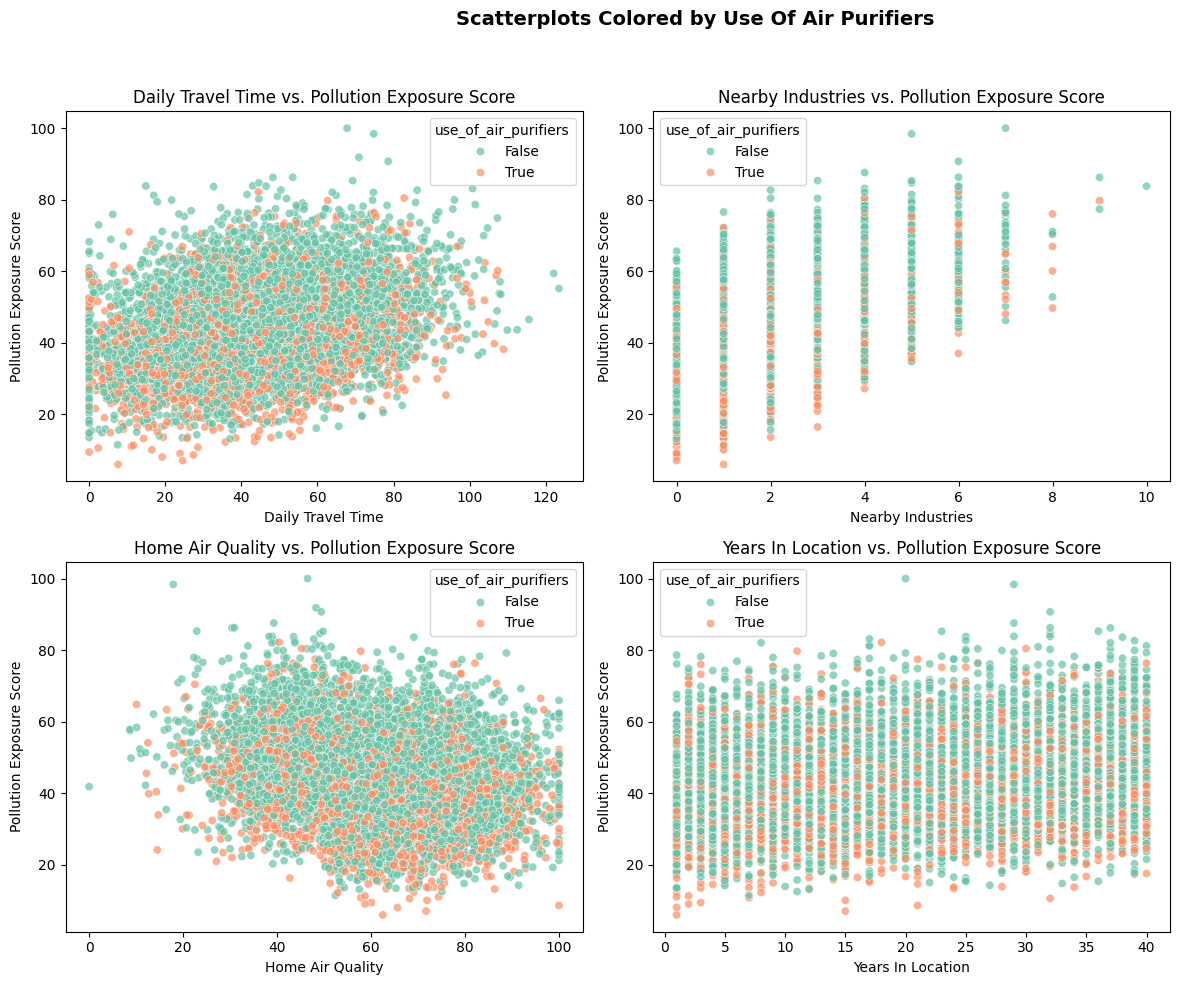

In [13]:
# Scatterplot pairs
scatter_pairs = [
    ('daily_travel_time', 'pollution_exposure_score'),
    ('nearby_industries', 'pollution_exposure_score'),
    ('home_air_quality', 'pollution_exposure_score'),
    ('years_in_location', 'pollution_exposure_score'),
]

# Hue features to iterate over
hue_features = [
    "vehicle_ownership",
    "location_type",
    "green_space_access",
    "work_location_type",
    "awareness_level",
    "risk_category",
    "smoker_in_household",
    "use_of_air_purifiers"
]

# Plot one figure per hue feature
for hue_feature in hue_features:
    fig, axes = plt.subplots(2, 2, figsize=(14, 10))
    axes = axes.flatten()

    for ax, (x_col, y_col) in zip(axes, scatter_pairs):
        sns.scatterplot(
            data=df,
            x=x_col,
            y=y_col,
            hue=hue_feature,
            alpha=0.7,
            palette="Set2",
            ax=ax
        )
        ax.set_title(
            f"{x_col.replace('_', ' ').title()} vs. {y_col.replace('_', ' ').title()}",
            fontsize=12
        )
        ax.set_xlabel(x_col.replace('_', ' ').title())
        ax.set_ylabel(y_col.replace('_', ' ').title())

    # Put legend outside to keep plots clean
    handles, labels = axes[0].get_legend_handles_labels()

    fig.suptitle(f"Scatterplots Colored by {hue_feature.replace('_', ' ').title()}",
                 fontsize=14, fontweight="bold")
    plt.tight_layout(rect=[0, 0, 0.85, 0.95])
    plt.show()

**IMPUTING**

In [15]:
df_imputed = df.copy()

In [16]:
# Numerical columns

# Median
df_imputed["daily_travel_time_missing"] = df_imputed["daily_travel_time"].isna().astype(int)
df_imputed["daily_travel_time"] = df_imputed["daily_travel_time"].fillna(df_imputed["daily_travel_time"].median())

# Median
df_imputed["nearby_industries_missing"] = df_imputed["nearby_industries"].isna().astype(int)
df_imputed["nearby_industries"] = df_imputed["nearby_industries"].fillna(df_imputed["nearby_industries"].median())

# Median
df_imputed["years_in_location_missing"] = df_imputed["years_in_location"].isna().astype(int)
df_imputed["years_in_location"] = df_imputed["years_in_location"].fillna(df_imputed["years_in_location"].median())

In [17]:
# Categorical columns

# Constant
df_imputed["vehicle_ownership_missing"] = df_imputed["vehicle_ownership"].isna().astype(int)
df_imputed["vehicle_ownership"] = df_imputed["vehicle_ownership"].fillna("Missing")

# Mode
df_imputed["green_space_access_missing"] = df_imputed["green_space_access"].isna().astype(int)
df_imputed["green_space_access"] = df_imputed["green_space_access"].fillna(df_imputed["green_space_access"].mode()[0])

# Constant
df_imputed["work_location_type_missing"] = df_imputed["work_location_type"].isna().astype(int)
df_imputed["work_location_type"] = df_imputed["work_location_type"].fillna("Missing")

# Constant
df_imputed["awareness_level_missing"] = df_imputed["awareness_level"].isna().astype(int)
df_imputed["awareness_level"] = df_imputed["awareness_level"].fillna("Missing")

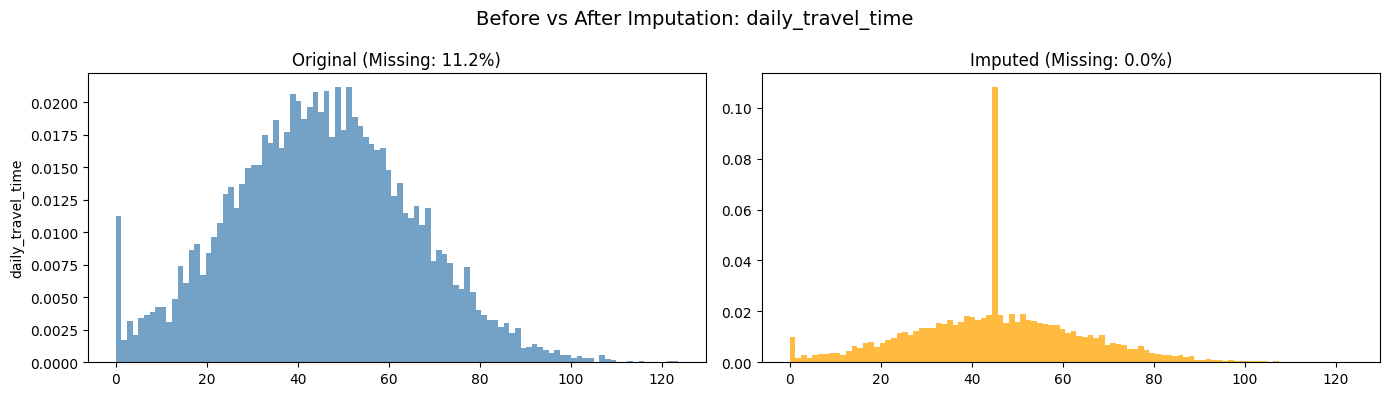

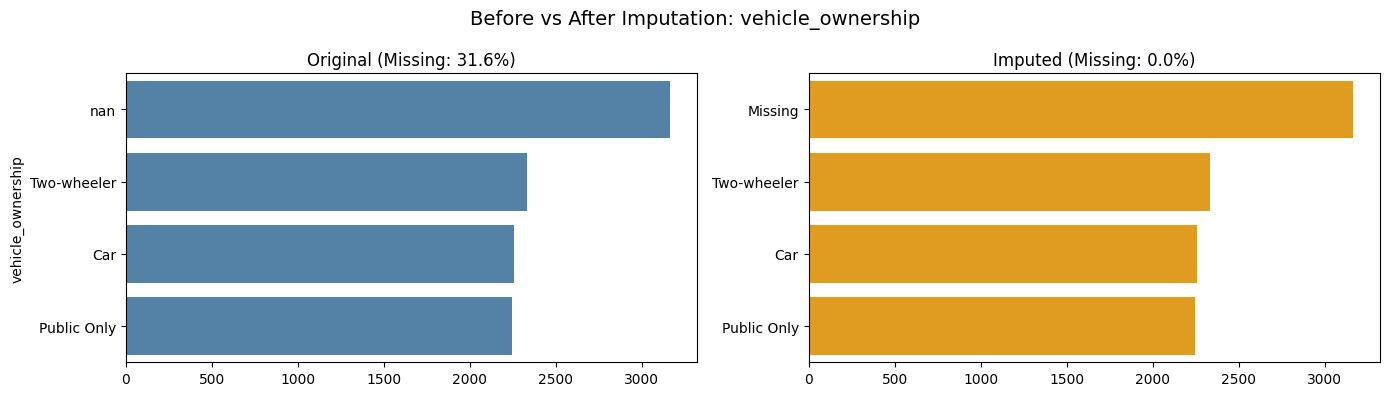

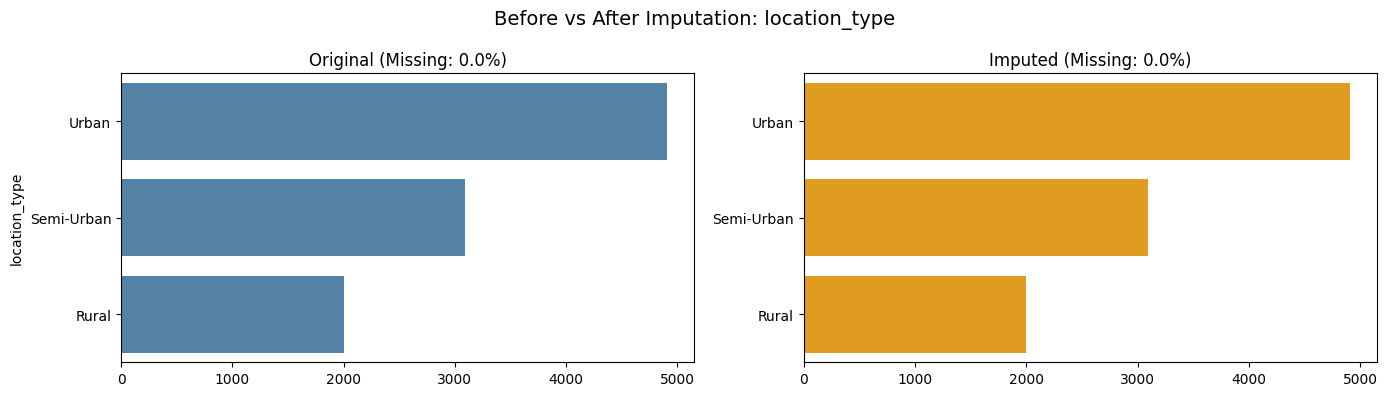

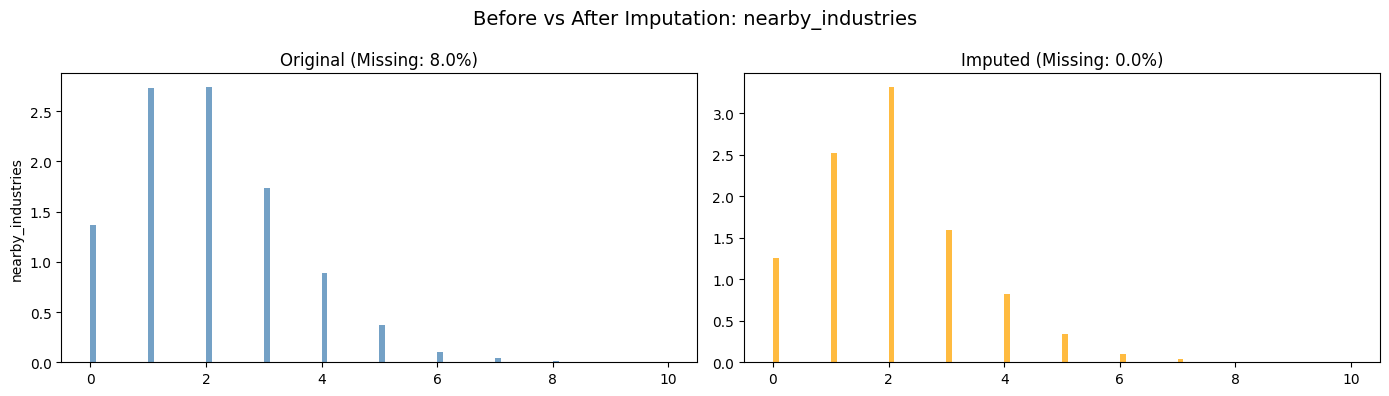

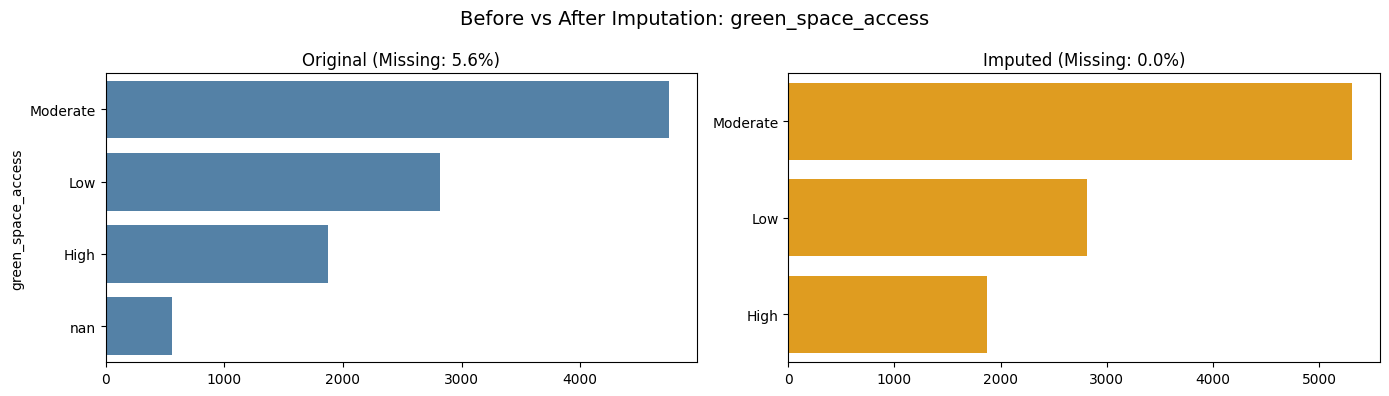

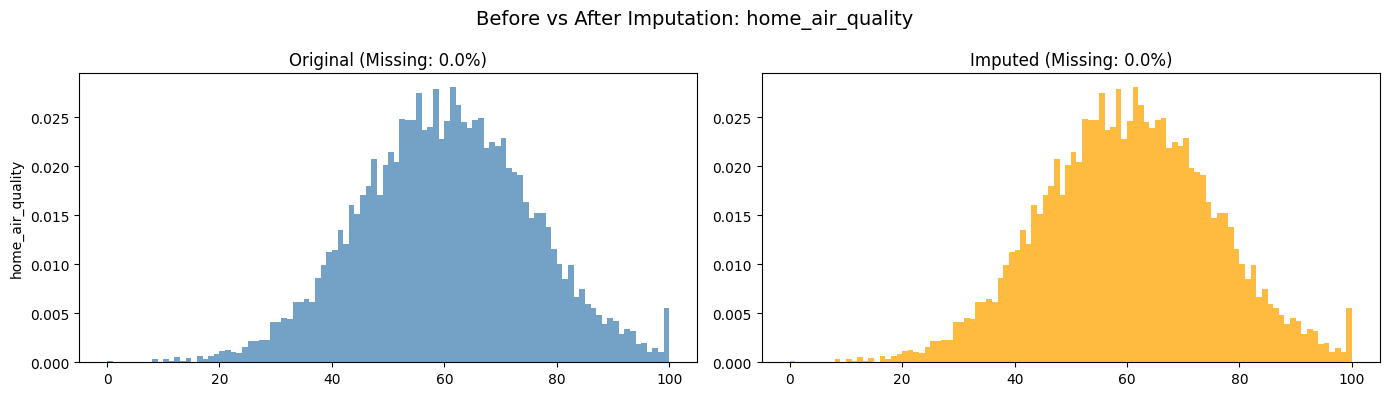

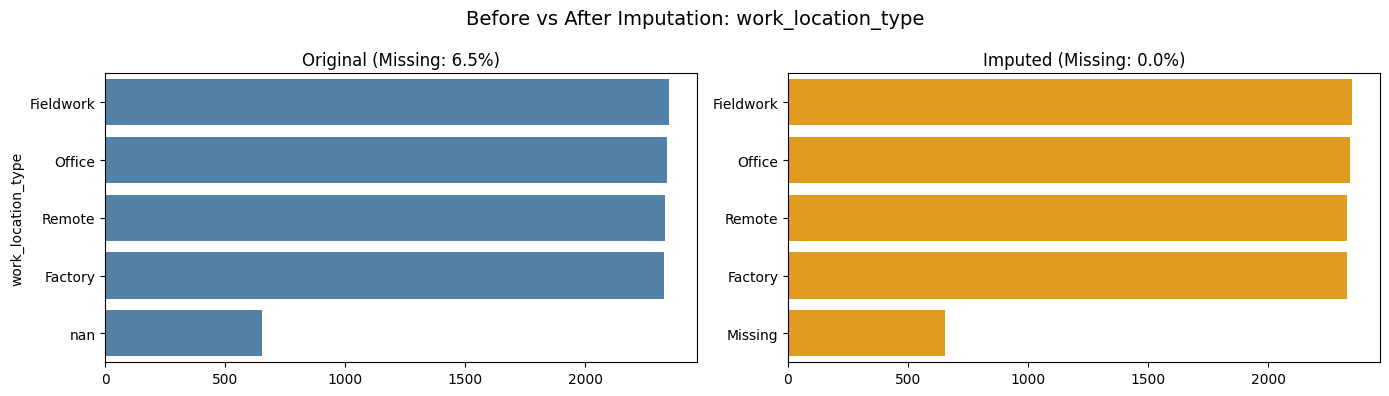

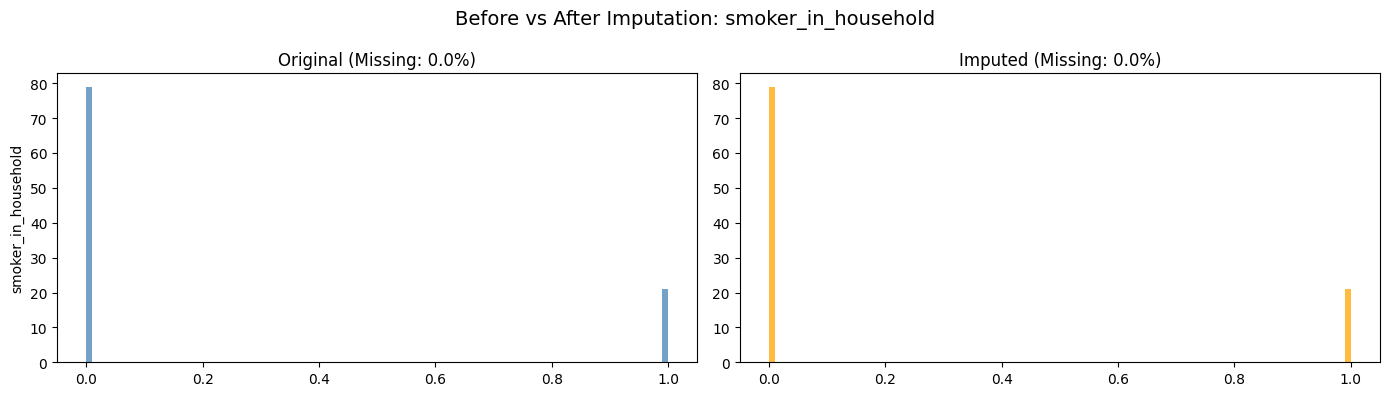

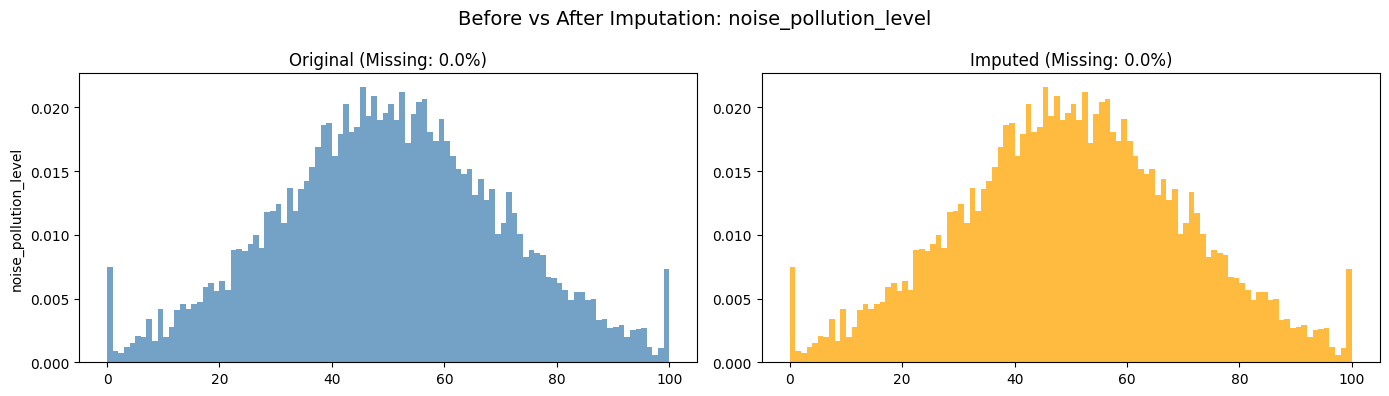

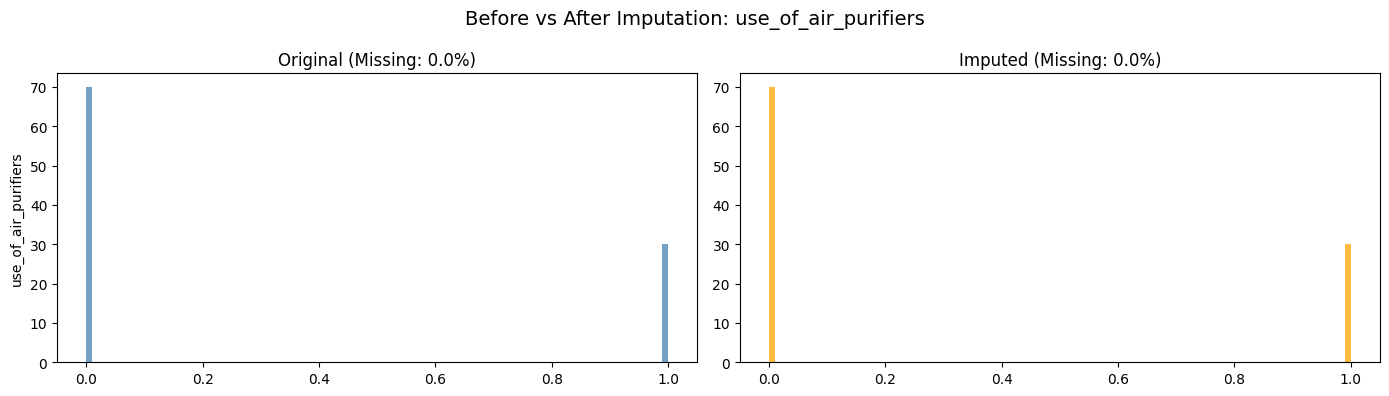

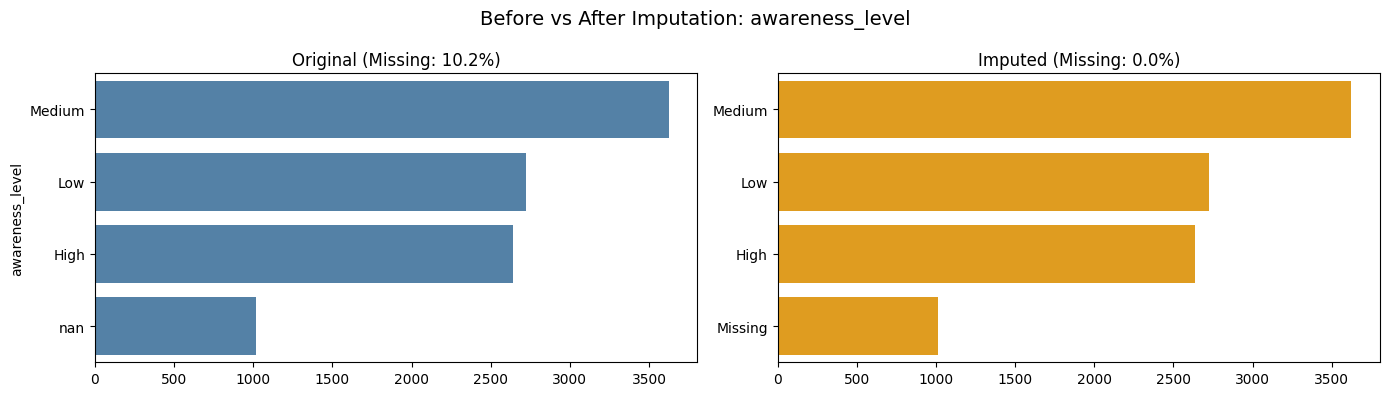

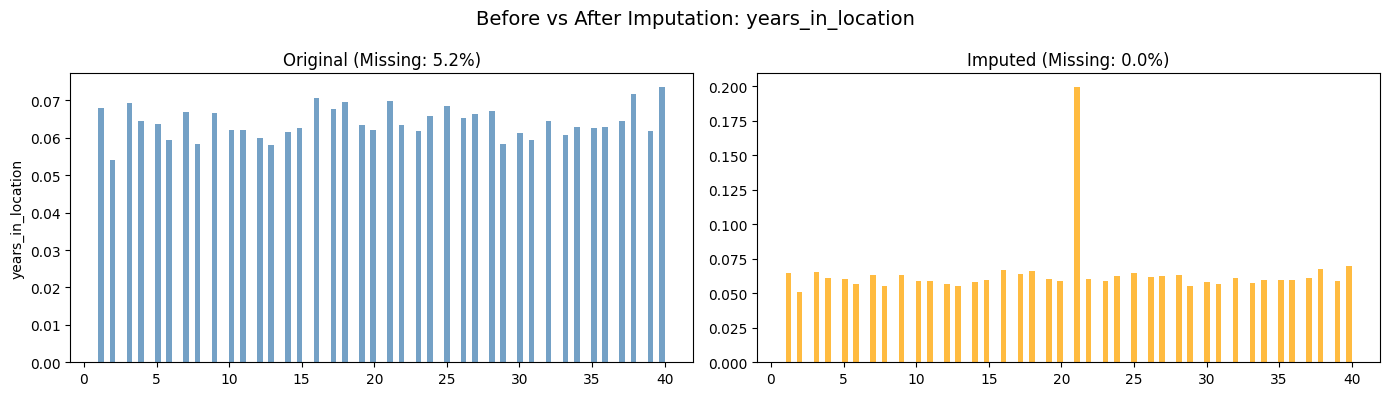

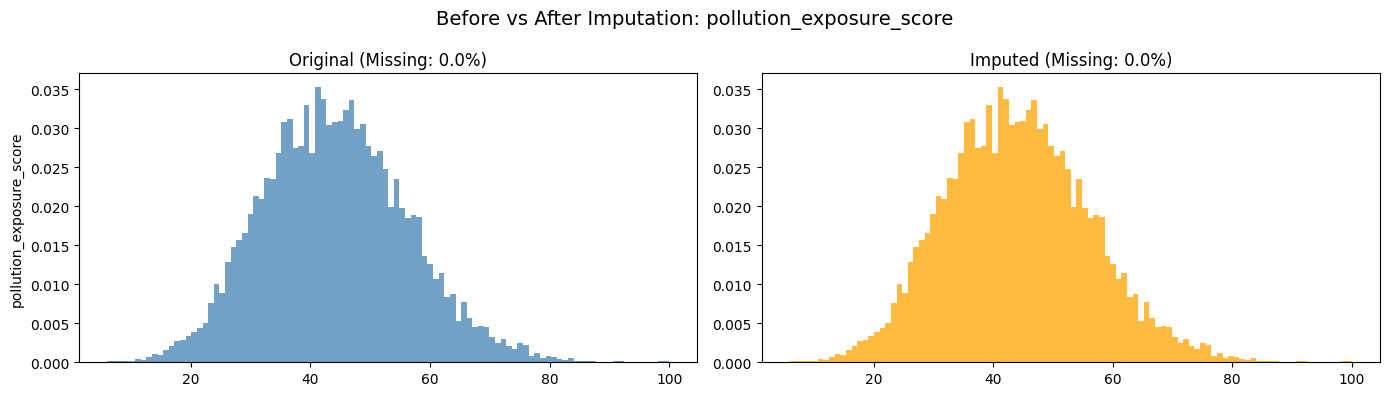

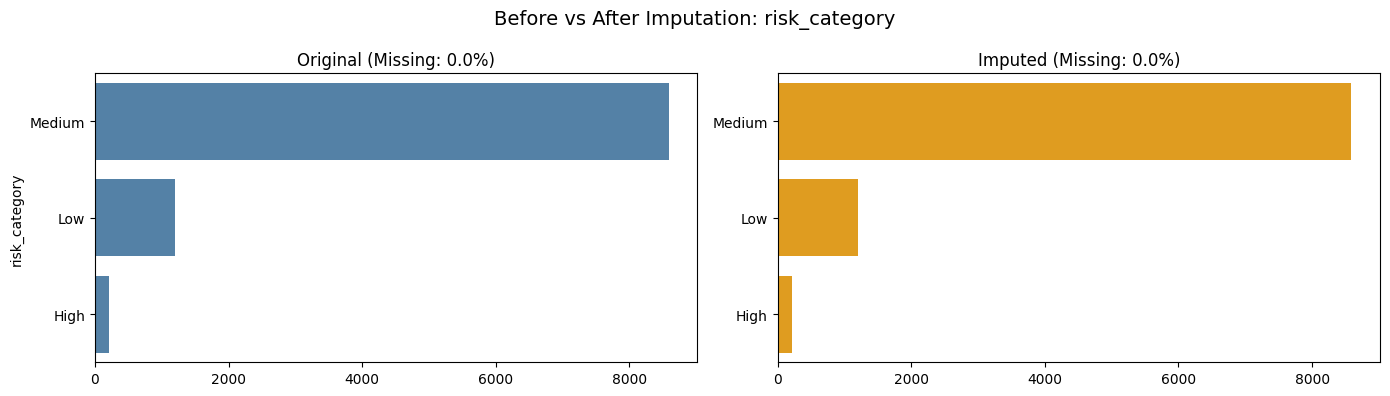

In [18]:
import matplotlib.pyplot as plt
import seaborn as sns

def plot_before_after(df, df_imputed, cols, bins=50):
    """
    Plots each column before and after imputation.
    Left plot = original df
    Right plot = df_imputed
    Automatically handles numeric + categorical columns.
    """

    for col in cols:
        if col not in df.columns or col not in df_imputed.columns:
            print(f"⚠️ Column '{col}' not found in one of the dataframes.")
            continue

        # Detect type
        is_numeric = pd.api.types.is_numeric_dtype(df[col])

        # Create side-by-side figure
        fig, axes = plt.subplots(1, 2, figsize=(14, 4))
        fig.suptitle(f"Before vs After Imputation: {col}", fontsize=14)

        # ---------------------------
        # LEFT PLOT → Before Imputation
        # ---------------------------
        if is_numeric:
            sns.histplot(
                df[col].dropna(),
                bins=bins,
                ax=axes[0],
                color="steelblue",
                edgecolor=None,
                stat="density"
            )
        else:
            # Categorical → barplot
            counts = df[col].value_counts(dropna=False)
            sns.barplot(
                x=counts.values,
                y=counts.index.astype(str),
                ax=axes[0],
                color="steelblue"
            )

        missing_before = df[col].isna().mean() * 100
        axes[0].set_title(f"Original (Missing: {missing_before:.1f}%)")
        axes[0].set_xlabel("")
        axes[0].set_ylabel(col)

        # ---------------------------
        # RIGHT PLOT → After Imputation
        # ---------------------------
        if is_numeric:
            sns.histplot(
                df_imputed[col].dropna(),
                bins=bins,
                ax=axes[1],
                color="orange",
                edgecolor=None,
                stat="density"
            )
        else:
            counts_imp = df_imputed[col].value_counts(dropna=False)
            sns.barplot(
                x=counts_imp.values,
                y=counts_imp.index.astype(str),
                ax=axes[1],
                color="orange"
            )

        missing_after = df_imputed[col].isna().mean() * 100
        axes[1].set_title(f"Imputed (Missing: {missing_after:.1f}%)")
        axes[1].set_xlabel("")
        axes[1].set_ylabel("")

        plt.tight_layout()
        plt.show()


plot_before_after(df, df_imputed, df.columns.tolist(), bins=100)

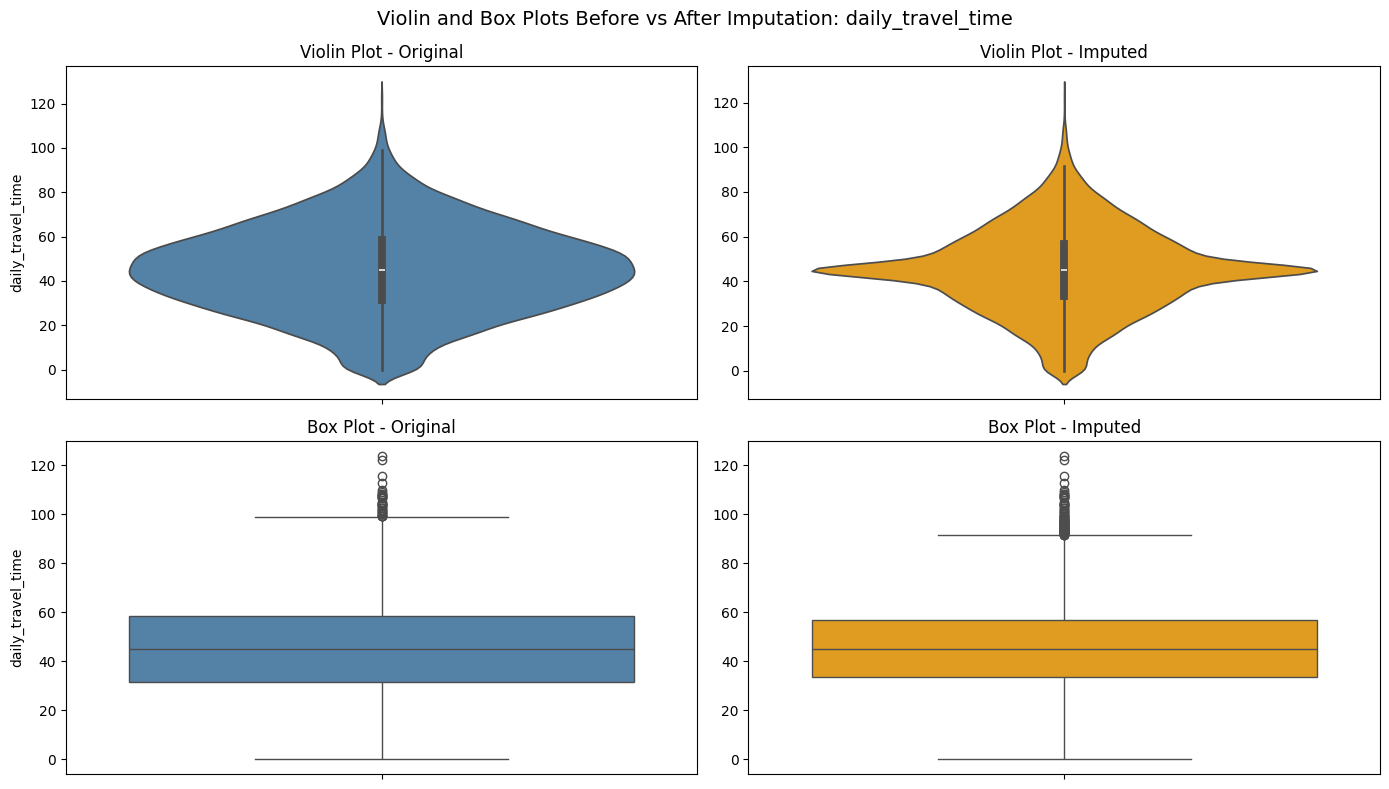

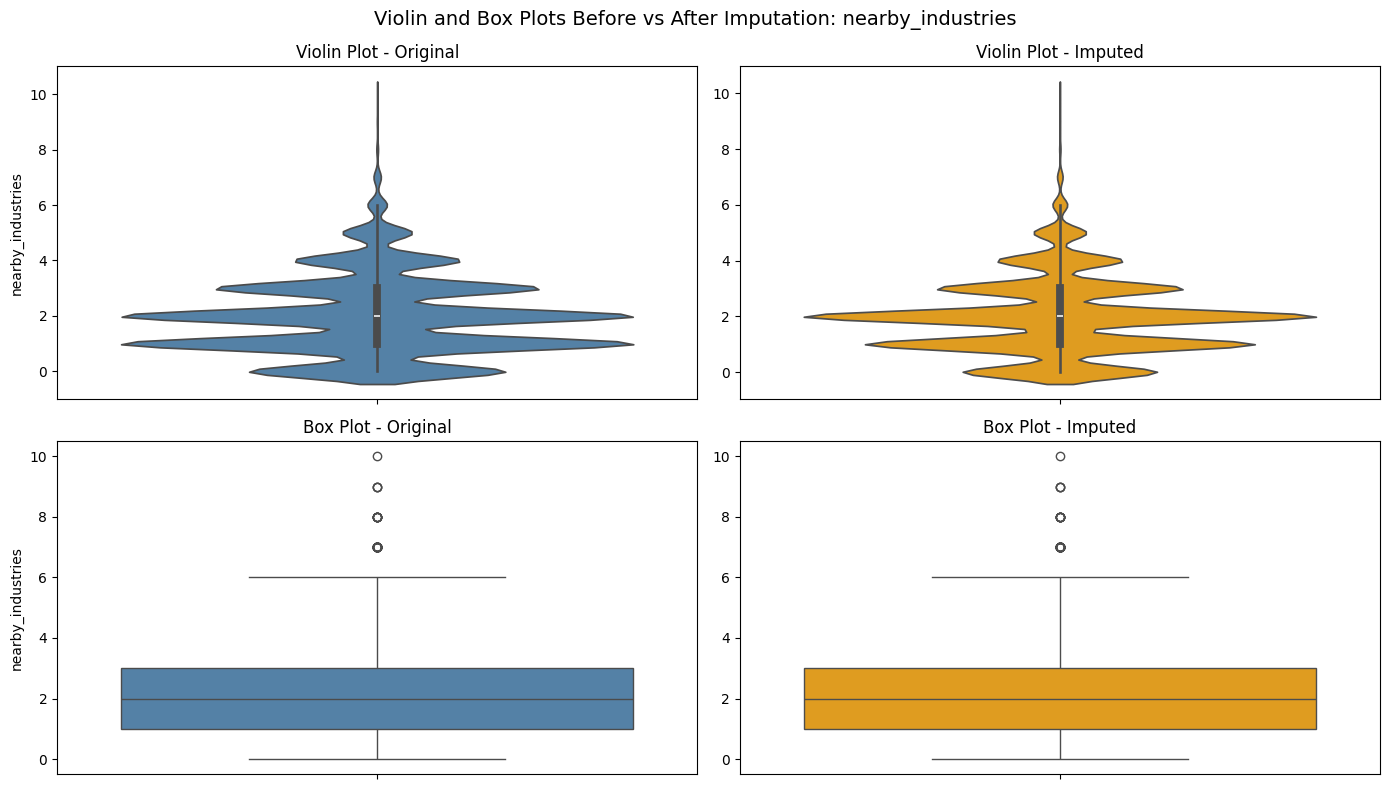

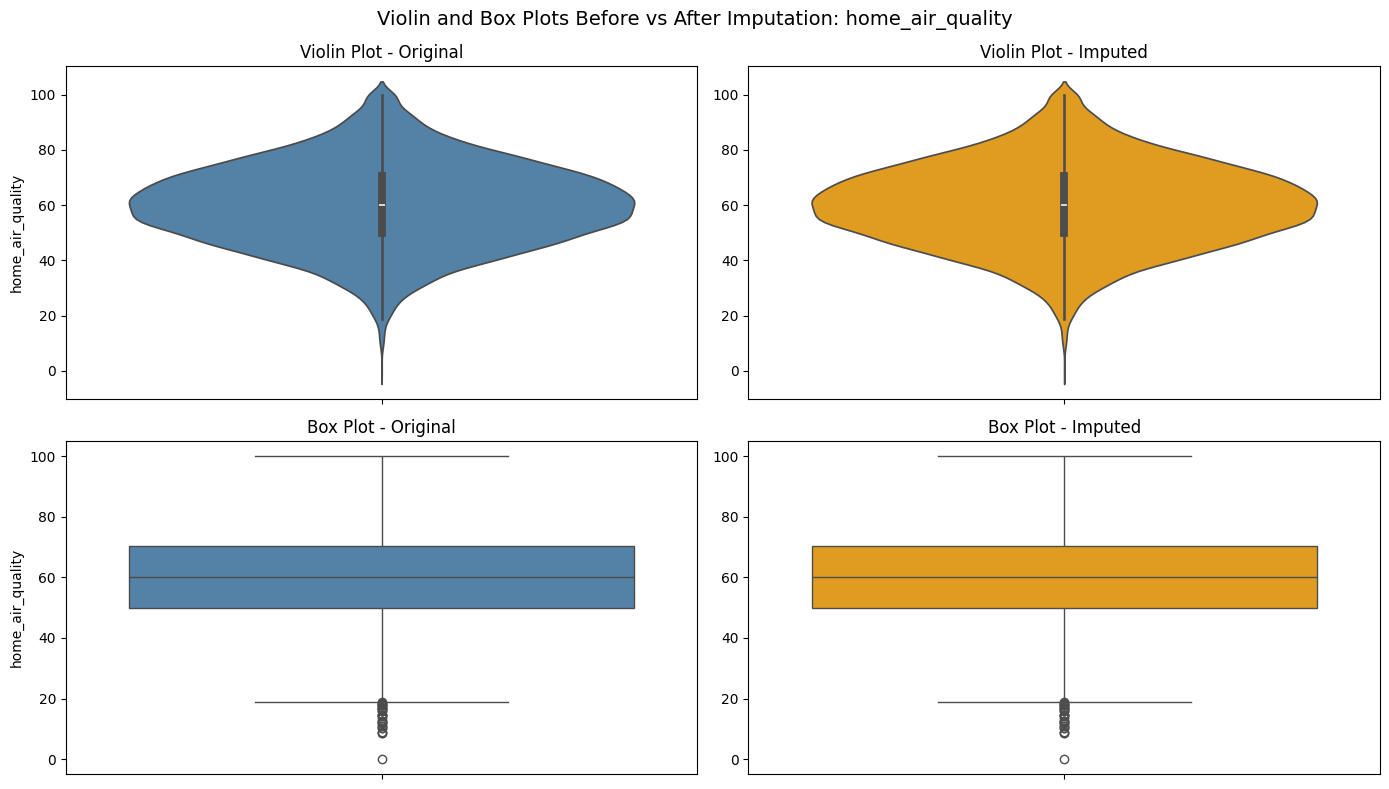

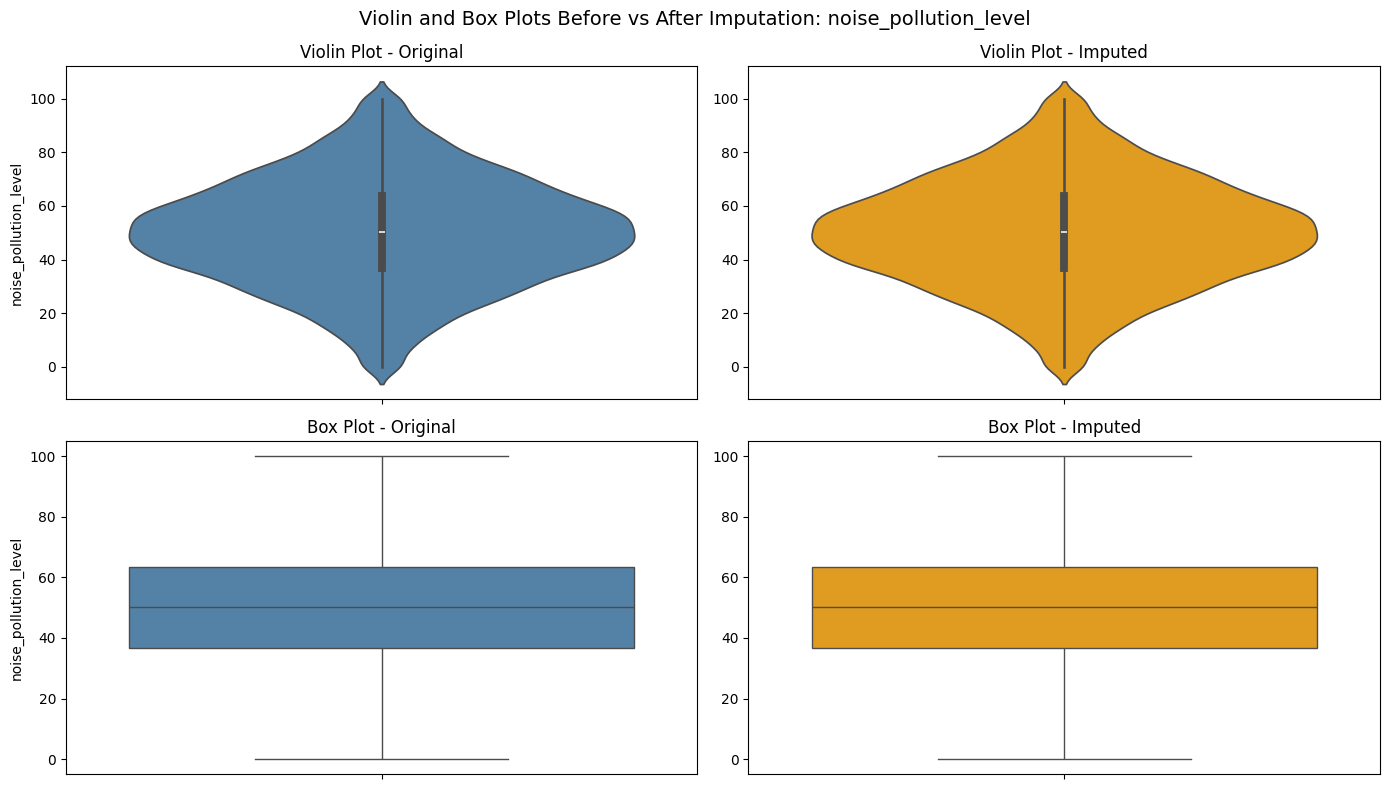

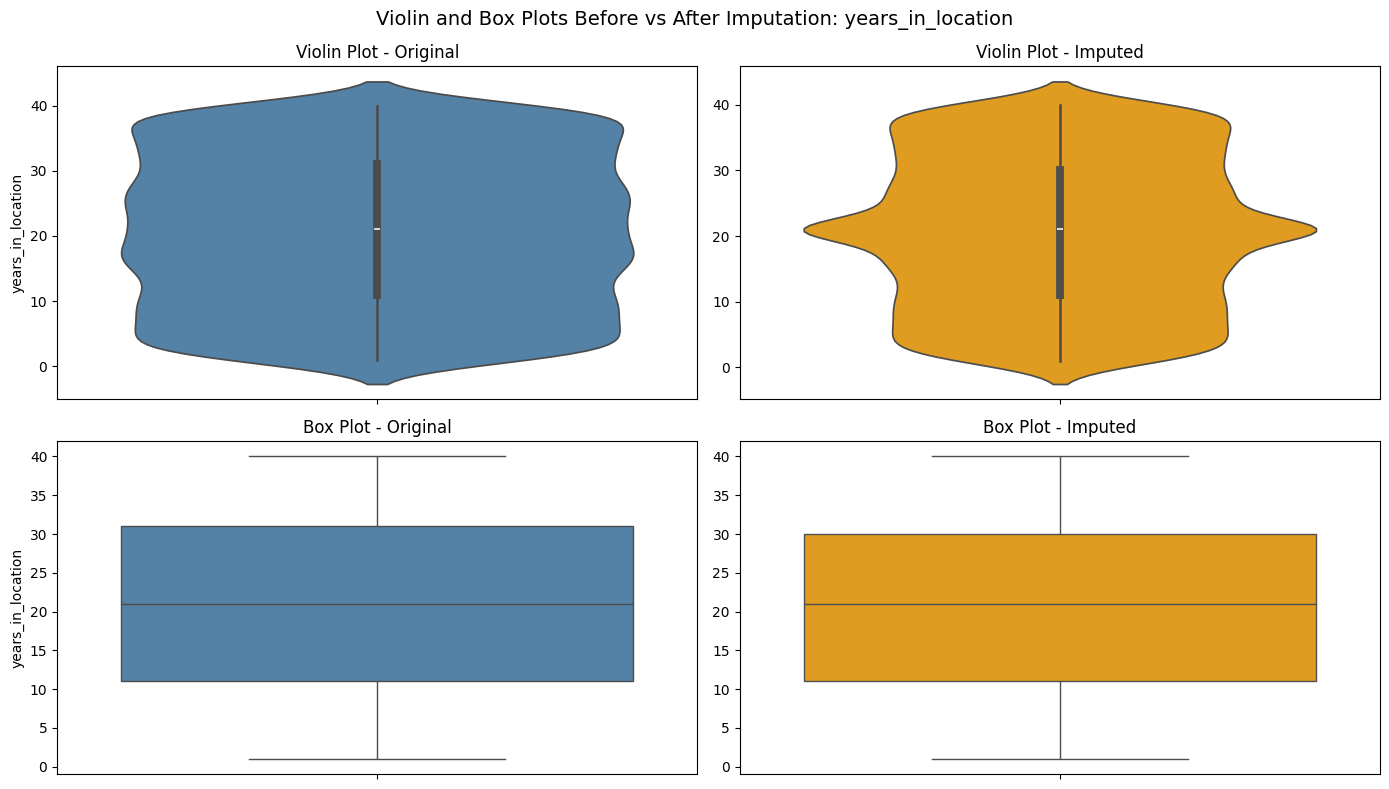

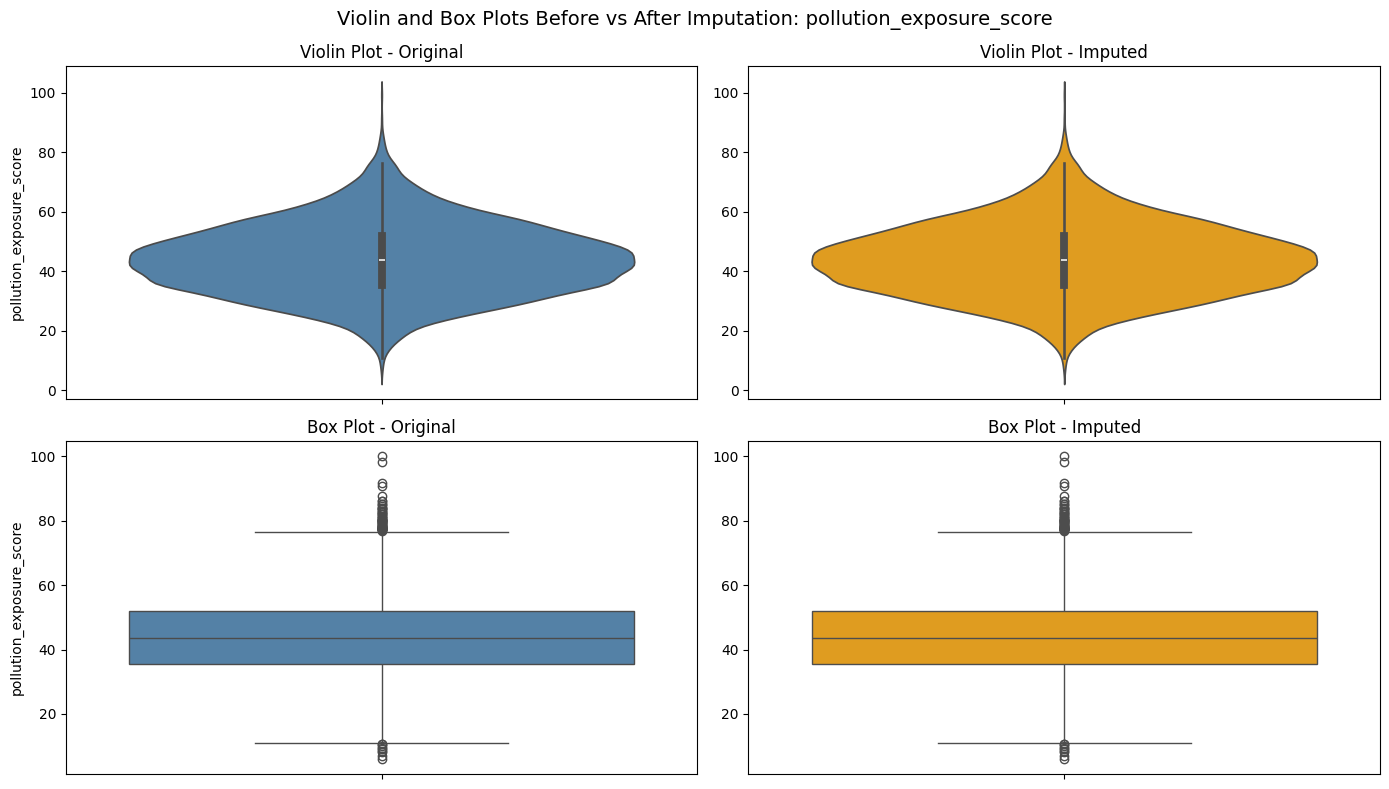

In [19]:
# Plot violin plots before and after imputation and box plots before and after imputation in for columns
def plot_violin_box_before_after(df, df_imputed, cols):
    for col in cols:
        if col not in df.columns or col not in df_imputed.columns:
            print(f"⚠️ Column '{col}' not found in one of the dataframes.")
            continue

        # Create side-by-side figure
        fig, axes = plt.subplots(2, 2, figsize=(14, 8))
        fig.suptitle(f"Violin and Box Plots Before vs After Imputation: {col}", fontsize=14)

        # Violin plot before imputation
        sns.violinplot(
            y=df[col],
            ax=axes[0, 0],
            color="steelblue"
        )
        axes[0, 0].set_title("Violin Plot - Original")
        axes[0, 0].set_ylabel(col)

        # Violin plot after imputation
        sns.violinplot(
            y=df_imputed[col],
            ax=axes[0, 1],
            color="orange"
        )
        axes[0, 1].set_title("Violin Plot - Imputed")
        axes[0, 1].set_ylabel("")

        # Box plot before imputation
        sns.boxplot(
            y=df[col],
            ax=axes[1, 0],
            color="steelblue"
        )
        axes[1, 0].set_title("Box Plot - Original")
        axes[1, 0].set_ylabel(col)

        # Box plot after imputation
        sns.boxplot(
            y=df_imputed[col],
            ax=axes[1, 1],
            color="orange"
        )
        axes[1, 1].set_title("Box Plot - Imputed")
        axes[1, 1].set_ylabel("")
        plt.tight_layout()
        plt.show()


plot_violin_box_before_after(df, df_imputed, numerical_cols)

**MODELING (REGRESSION)**

In [20]:
ordinal_cols = {
    "green_space_access": ["Low", "Moderate", "High", "Missing"],
    "awareness_level": ["Low", "Medium", "High", "Missing"],
    # "risk_category": ["Low", "Medium", "High"],
}

nominal_cols = [
    "vehicle_ownership",
    "location_type",
    "work_location_type",
]

target = "pollution_exposure_score"

numerical_cols = (
    df_imputed.select_dtypes(include="number")
    .columns
    .drop([target])
    .tolist()
)

X = df_imputed.drop(columns=[target, "risk_category"])
y = df_imputed[target]


In [21]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)


In [22]:
from sklearn.preprocessing import OrdinalEncoder, OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer

ordinal_encoder = OrdinalEncoder(categories=list(ordinal_cols.values()))

onehot_encoder = OneHotEncoder(handle_unknown="ignore")


XGBoost

In [23]:
from xgboost import XGBRegressor
from sklearn.pipeline import Pipeline
from sklearn.model_selection import RandomizedSearchCV

preprocess_xgb = ColumnTransformer(
    transformers=[
        ("ord", ordinal_encoder, list(ordinal_cols.keys())),
        ("nom", OrdinalEncoder(), nominal_cols),
        ("num", "passthrough", numerical_cols),
    ]
)

xgb_pipe = Pipeline([
    ("prep", preprocess_xgb),
    ("model", XGBRegressor(tree_method="hist", random_state=42))
])

xgb_params = {
    "model__n_estimators": [200, 400, 800],
    "model__max_depth": [4, 6, 8, 10],
    "model__learning_rate": [0.01, 0.03, 0.1],
    "model__subsample": [0.7, 0.9, 1.0],
    "model__colsample_bytree": [0.7, 0.9, 1.0],
}

xgb_search = RandomizedSearchCV(
    xgb_pipe, xgb_params,
    n_iter=20, cv=5, scoring="neg_mean_squared_error",
    n_jobs=-1, verbose=1
)


Random forest

In [24]:
from sklearn.ensemble import RandomForestRegressor

rf_pipe = Pipeline([
    ("prep", preprocess_xgb),
    ("model", RandomForestRegressor(random_state=42))
])

rf_params = {
    "model__n_estimators": [200, 400, 800],
    "model__max_depth": [None, 10, 20, 30],
    "model__min_samples_split": [2, 5, 10],
    "model__min_samples_leaf": [1, 2, 4],
}

rf_search = RandomizedSearchCV(
    rf_pipe, rf_params,
    n_iter=20, cv=5, scoring="neg_mean_squared_error",
    n_jobs=-1, verbose=1
)


Linear Regression

In [25]:
from sklearn.linear_model import ElasticNet, Lasso, Ridge
from sklearn.linear_model import LinearRegression

preprocess_linear = ColumnTransformer(
    transformers=[
        ("ord", ordinal_encoder, list(ordinal_cols.keys())),
        ("nom", onehot_encoder, nominal_cols),
        ("num", StandardScaler(), numerical_cols),
    ]
)

ols_pipe = Pipeline([
    ("prep", preprocess_linear),
    ("model", LinearRegression())
])

ols_params = {}

ridge_pipe = Pipeline([
    ("prep", preprocess_linear),
    ("model", Ridge())
])

ridge_params = {
    "model__alpha": [0.1, 1.0, 10, 50, 100, 200]
}

lasso_pipe = Pipeline([
    ("prep", preprocess_linear),
    ("model", Lasso(max_iter=5000))
])

lasso_params = {
    "model__alpha": [0.0001, 0.001, 0.01, 0.1, 1.0],
}

elastic_pipe = Pipeline([
    ("prep", preprocess_linear),
    ("model", ElasticNet(max_iter=5000))
])

elastic_params = {
    "model__alpha": [0.0001, 0.001, 0.01, 0.1, 1.0],
    "model__l1_ratio": [0.1, 0.3, 0.5, 0.7, 0.9],  # 0=ridge, 1=lasso
}


linear_searches = {
    "OLS": RandomizedSearchCV(
        ols_pipe, ols_params,
        n_iter=1, cv=5, scoring="neg_mean_squared_error",
        n_jobs=-1, verbose=1
    ),
    "Ridge": RandomizedSearchCV(
        ridge_pipe, ridge_params,
        n_iter=10, cv=5, scoring="neg_mean_squared_error",
        n_jobs=-1, verbose=1
    ),
    "Lasso": RandomizedSearchCV(
        lasso_pipe, lasso_params,
        n_iter=10, cv=5, scoring="neg_mean_squared_error",
        n_jobs=-1, verbose=1
    ),
    "ElasticNet": RandomizedSearchCV(
        elastic_pipe, elastic_params,
        n_iter=20, cv=5, scoring="neg_mean_squared_error",
        n_jobs=-1, verbose=1
    ),
}

SVR

In [26]:
from sklearn.svm import SVR

svm_pipe = Pipeline([
    ("prep", preprocess_linear),
    ("model", SVR())
])

svm_params = {
    "model__C": [1, 10, 100],
    "model__kernel": ["rbf", "poly"],
    "model__gamma": ["scale", "auto"],
    "model__degree": [2, 3],
}

svm_search = RandomizedSearchCV(
    svm_pipe, svm_params,
    n_iter=10, cv=5, scoring="neg_mean_squared_error",
    n_jobs=-1, verbose=1
)


KNN

In [27]:
from sklearn.neighbors import KNeighborsRegressor

knn_pipe = Pipeline([
    ("prep", preprocess_linear),
    ("model", KNeighborsRegressor())
])

knn_params = {
    "model__n_neighbors": [3, 5, 10, 20, 30],
    "model__weights": ["uniform", "distance"],
    "model__p": [1, 2],
}

knn_search = RandomizedSearchCV(
    knn_pipe, knn_params,
    n_iter=10, cv=5, scoring="neg_mean_squared_error",
    n_jobs=-1, verbose=1
)


In [28]:
searches = {
    "XGB": xgb_search,
    "RandomForest": rf_search,
    "SVR": svm_search,
    "KNN": knn_search,
    **linear_searches
}

best_models = {}
results = {}

for name, search in searches.items():
    print(f"\n Training {name}...\n")
    search.fit(X_train, y_train)
    
    best_models[name] = search.best_estimator_
    results[name] = search.best_score_
    
    print(f"Best score ({name}): {search.best_score_}")
    print(f"Best params: {search.best_params_}")



 Training XGB...

Fitting 5 folds for each of 20 candidates, totalling 100 fits
Best score (XGB): -17.493882672622334
Best params: {'model__subsample': 0.7, 'model__n_estimators': 400, 'model__max_depth': 4, 'model__learning_rate': 0.03, 'model__colsample_bytree': 0.9}

 Training RandomForest...

Fitting 5 folds for each of 20 candidates, totalling 100 fits
Best score (RandomForest): -25.78016263199519
Best params: {'model__n_estimators': 800, 'model__min_samples_split': 5, 'model__min_samples_leaf': 2, 'model__max_depth': 20}

 Training SVR...

Fitting 5 folds for each of 10 candidates, totalling 50 fits
Best score (SVR): -24.27652596364323
Best params: {'model__kernel': 'rbf', 'model__gamma': 'auto', 'model__degree': 3, 'model__C': 10}

 Training KNN...

Fitting 5 folds for each of 10 candidates, totalling 50 fits
Best score (KNN): -50.04677672644283
Best params: {'model__weights': 'distance', 'model__p': 1, 'model__n_neighbors': 10}

 Training OLS...

Fitting 5 folds for each of 1 

Compare Best Models

In [29]:
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import pandas as pd

comparison = []

for name, model in best_models.items():
    preds = model.predict(X_test)
    comparison.append({
        "Model": name,
        "RMSE": np.sqrt(mean_squared_error(y_test, preds)),
        "MAE": mean_absolute_error(y_test, preds),
        "R2": r2_score(y_test, preds),
    })

comparison_df = pd.DataFrame(comparison).sort_values("RMSE")
print(comparison_df)


          Model      RMSE       MAE        R2
0           XGB  4.343914  3.163951  0.872125
2           SVR  5.052598  3.793852  0.826997
1  RandomForest  5.171020  3.908798  0.818792
6         Lasso  5.592905  4.353282  0.788018
7    ElasticNet  5.593216  4.353112  0.787995
5         Ridge  5.593273  4.353105  0.787990
4           OLS  5.593313  4.353079  0.787987
3           KNN  7.057480  5.420178  0.662462


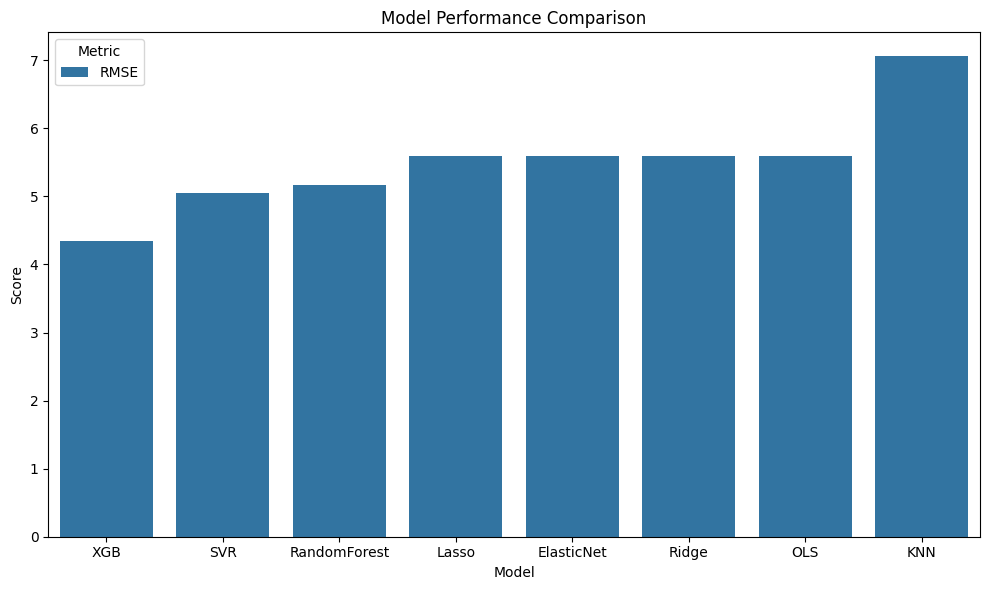

In [30]:
import matplotlib.pyplot as plt
import seaborn as sns

# Plot RMSE, MAE, and R2 for each model as grouped bars
comparison_df = pd.DataFrame(comparison).sort_values("RMSE")
metrics = ["RMSE"]

plt.figure(figsize=(10, 6))
comparison_melted = comparison_df.melt(id_vars="Model", value_vars=metrics, var_name="Metric", value_name="Score")
sns.barplot(data=comparison_melted, x="Model", y="Score", hue="Metric")
plt.title("Model Performance Comparison")
plt.ylabel("Score")
plt.xlabel("Model")
plt.legend(title="Metric")
plt.tight_layout()
plt.show()


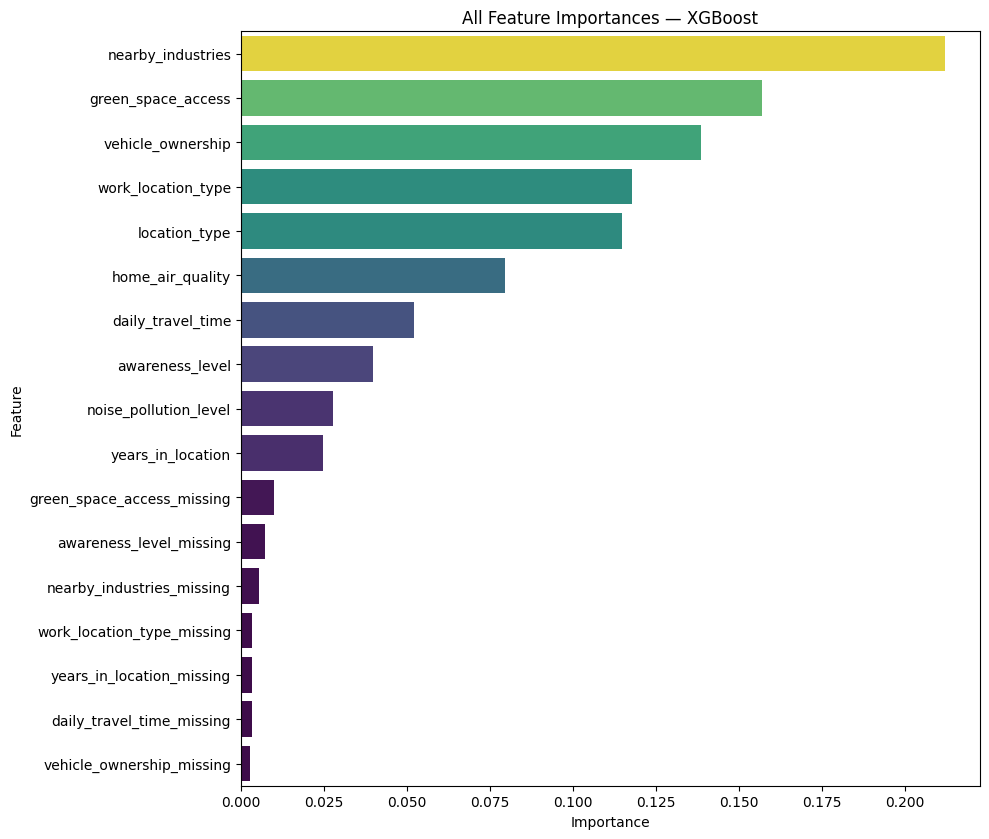

In [31]:
xgb_model = best_models["XGB"]

def get_feature_names(preprocessor, numeric, ordinal, nominal):
    output = []

    transformers = preprocessor.transformers_

    for name, trans, cols in transformers:
        if name == "num":
            output.extend(cols)

        elif name == "ord":
            output.extend(cols)

        elif name == "nom":
            ohe = trans
            new_cols = ohe.get_feature_names_out(cols)
            output.extend(new_cols)

    return output


preprocessor = xgb_model.named_steps["prep"]

feature_names = get_feature_names(
    preprocessor,
    numerical_cols,
    list(ordinal_cols.keys()),
    nominal_cols
)

xgb_reg = xgb_model.named_steps["model"]
importances = xgb_reg.feature_importances_


fi_df = pd.DataFrame({
    "feature": feature_names,
    "importance": importances
}).sort_values("importance", ascending=False)


plt.figure(figsize=(10, len(fi_df) / 2))
sns.barplot(
    data=fi_df,
    y="feature",
    x="importance",
    palette="viridis",
    hue="importance",
    dodge=False,
    legend=False,
)

plt.title("All Feature Importances — XGBoost")
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.tight_layout()
plt.show()



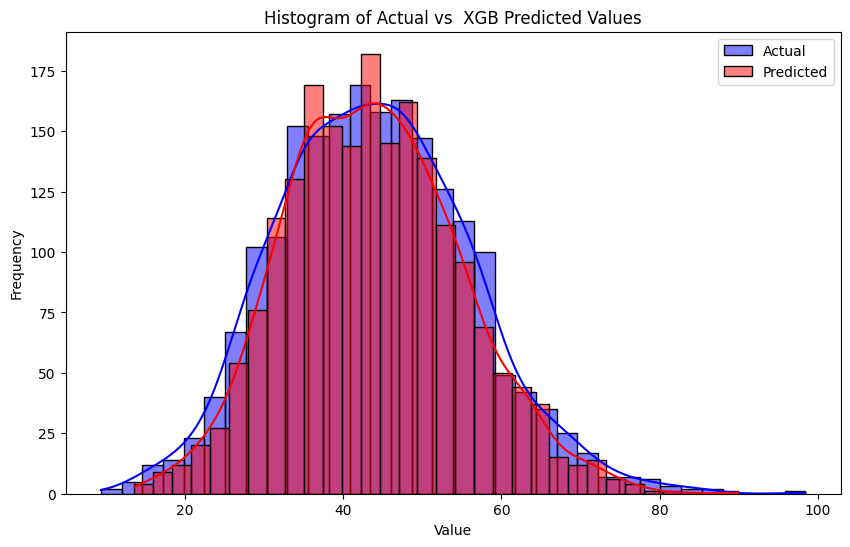

In [32]:
# plot histogram of real y test and predicted y test from the best model
plt.figure(figsize=(10, 6))
sns.histplot(y_test, color="blue", label="Actual", kde=True)
sns.histplot(best_models["XGB"].predict(X_test), color="red", label="Predicted", kde=True)
plt.legend()
plt.title("Histogram of Actual vs  XGB Predicted Values")
plt.xlabel("Value")
plt.ylabel("Frequency")
plt.show()

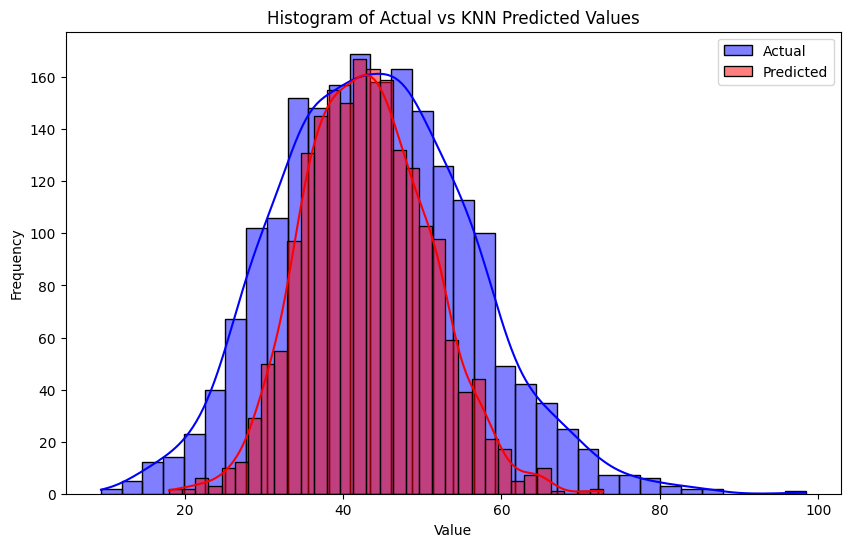

In [33]:
# plot histogram of real y test and predicted y test from the best model
plt.figure(figsize=(10, 6))
sns.histplot(y_test, color="blue", label="Actual", kde=True)
sns.histplot(best_models["KNN"].predict(X_test), color="red", label="Predicted", kde=True)
plt.legend()
plt.title("Histogram of Actual vs KNN Predicted Values")
plt.xlabel("Value")
plt.ylabel("Frequency")
plt.show()

In [34]:
all_features = list(X_train.columns)
len(all_features)

fi_ranked = fi_df.sort_values("importance", ascending=True)  # least → most
ordered_features = list(fi_ranked["feature"])

def map_back_to_original(feature_names):
    original_map = {f: None for f in feature_names}

    for col in nominal_cols:
        for f in feature_names:
            if f.startswith(col + "_"):
                original_map[f] = col
    
    for col in ordinal_cols.keys():
        for f in feature_names:
            if f == col:
                original_map[f] = col

    for col in numerical_cols:
        for f in feature_names:
            if f == col:
                original_map[f] = col

    return original_map

mapped = map_back_to_original(feature_names)

original_importance = (
    fi_df.assign(original=fi_df["feature"].map(mapped))
    .groupby("original")["importance"]
    .sum()
    .sort_values()
)

features_by_importance = list(original_importance.index)  # least → most important

from sklearn.metrics import mean_squared_error, r2_score

def train_with_subset(remove_features):
    # keep all except removed
    keep_cols = [c for c in all_features if c not in remove_features]

    # split train/test with subset
    X_train_sub = X_train[keep_cols]
    X_test_sub = X_test[keep_cols]

    # Rebuild pipeline with correct ColumnTransformer
    ord_cols = [c for c in ordinal_cols.keys() if c in keep_cols]
    nom_cols = [c for c in nominal_cols if c in keep_cols]
    num_cols = [c for c in numerical_cols if c in keep_cols]

    sub_preprocessor = ColumnTransformer(
        transformers=[
            ("ord", OrdinalEncoder(categories=[ordinal_cols[c] for c in ord_cols]), ord_cols),
            ("nom", OneHotEncoder(handle_unknown="ignore"), nom_cols),
            ("num", StandardScaler(), num_cols),
        ],
        remainder="drop"
    )

    sub_pipe = Pipeline([
        ("prep", sub_preprocessor),
        ("model", XGBRegressor(**best_models["XGB"].named_steps["model"].get_params()))
    ])

    sub_pipe.fit(X_train_sub, y_train)

    preds = sub_pipe.predict(X_test_sub)
    rmse = np.sqrt(mean_squared_error(y_test, preds))
    r2 = r2_score(y_test, preds)

    return rmse, r2, sub_pipe

results = []
removed = []

print("Starting backward elimination...\n")

for f in features_by_importance:
    removed.append(f)

    rmse, r2, model = train_with_subset(removed)

    results.append({
        "removed_features": removed.copy(),
        "last_removed": f,
        "num_features_left": len(all_features) - len(removed),
        "RMSE": rmse,
        "R2": r2
    })

    print(f"Removed: {f}, RMSE={rmse:.4f}, R²={r2:.4f}")

results_df = pd.DataFrame(results)
results_df


Starting backward elimination...

Removed: vehicle_ownership_missing, RMSE=4.3500, R²=0.8718
Removed: daily_travel_time_missing, RMSE=4.3283, R²=0.8730
Removed: years_in_location_missing, RMSE=4.3476, R²=0.8719
Removed: work_location_type_missing, RMSE=4.3247, R²=0.8733
Removed: nearby_industries_missing, RMSE=4.3236, R²=0.8733
Removed: awareness_level_missing, RMSE=4.3338, R²=0.8727
Removed: green_space_access_missing, RMSE=4.3591, R²=0.8712
Removed: years_in_location, RMSE=4.7910, R²=0.8444
Removed: noise_pollution_level, RMSE=5.1843, R²=0.8179
Removed: awareness_level, RMSE=5.5018, R²=0.7949
Removed: daily_travel_time, RMSE=6.4024, R²=0.7222
Removed: home_air_quality, RMSE=7.5973, R²=0.6089
Removed: green_space_access, RMSE=8.5731, R²=0.5019
Removed: nearby_industries, RMSE=10.4249, R²=0.2635


,removed_features,last_removed,num_features_left,RMSE,R2
0,[vehicle_ownership_missing],vehicle_ownership_missing,18,4.350028,0.871765
1,"[vehicle_ownership_missing, daily_travel_time_...",daily_travel_time_missing,17,4.328272,0.873044
2,"[vehicle_ownership_missing, daily_travel_time_...",years_in_location_missing,16,4.347647,0.871905
3,"[vehicle_ownership_missing, daily_travel_time_...",work_location_type_missing,15,4.324734,0.873252
4,"[vehicle_ownership_missing, daily_travel_time_...",nearby_industries_missing,14,4.323590,0.873319
5,"[vehicle_ownership_missing, daily_travel_time_...",awareness_level_missing,13,4.333823,0.872718
6,"[vehicle_ownership_missing, daily_travel_time_...",green_space_access_missing,12,4.359144,0.871227
7,"[vehicle_ownership_missing, daily_travel_time_...",years_in_location,11,4.791022,0.844446
8,"[vehicle_ownership_missing, daily_travel_time_...",noise_pollution_level,10,5.184319,0.817859
9,"[vehicle_ownership_missing, daily_travel_time_...",awareness_level,9,5.501830,0.794866


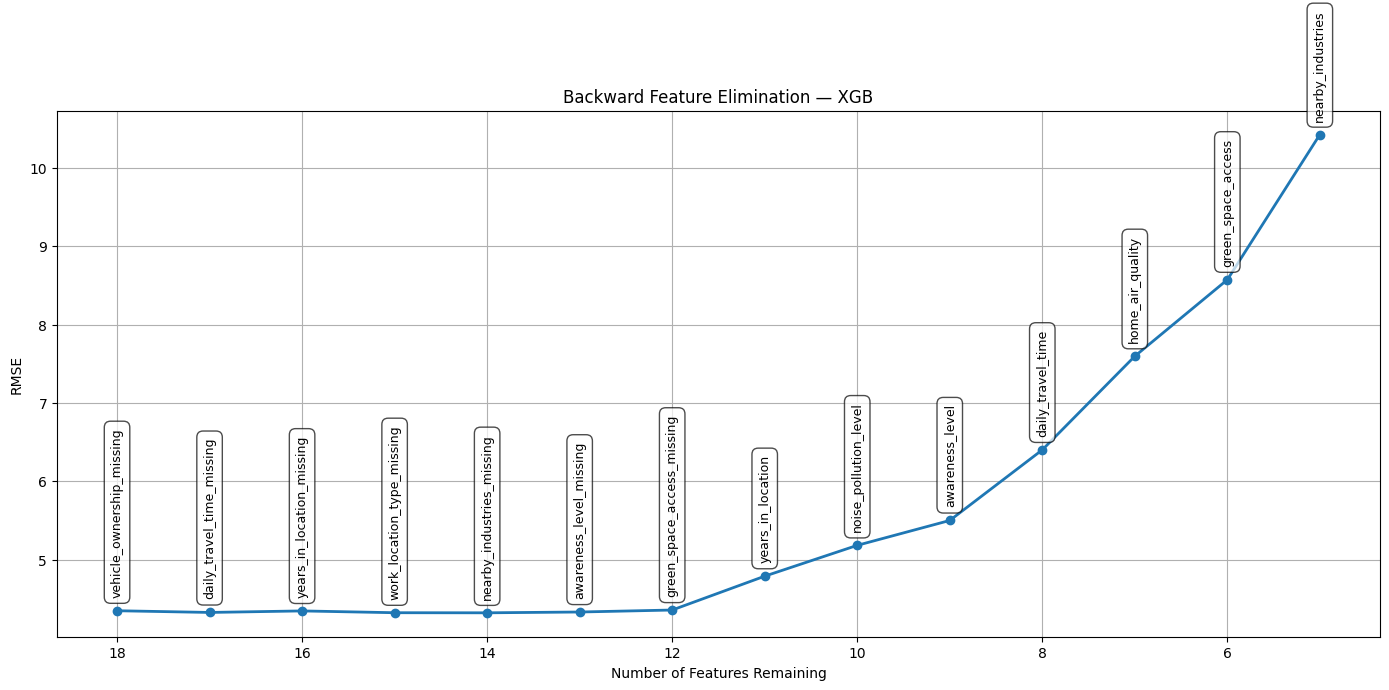

In [35]:
plt.figure(figsize=(14, 7))

x = results_df["num_features_left"]
y = results_df["RMSE"]
labels = results_df["last_removed"]

plt.plot(x, y, marker="o", linewidth=2)
plt.gca().invert_xaxis()
plt.xlabel("Number of Features Remaining")
plt.ylabel("RMSE")
plt.title("Backward Feature Elimination — XGB")
plt.grid(True)

# Add annotations above each point
for xi, yi, label in zip(x, y, labels):
    plt.annotate(
        text=label,
        xy=(xi, yi),
        xytext=(0, 12),    # shift text slightly above
        textcoords="offset points",
        ha="center",
        fontsize=9,
        rotation=90,
        bbox=dict(boxstyle="round,pad=0.5", fc="white", alpha=0.7)
    )

plt.tight_layout()
plt.show()

**MODELING (CLASSIFICATION)**

In [36]:
import pandas as pd

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OrdinalEncoder, OneHotEncoder, StandardScaler, LabelEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    f1_score,
    classification_report,
    confusion_matrix
)

from xgboost import XGBClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import RandomizedSearchCV


In [37]:
target = "risk_category"

# df_imputed is your already imputed dataset
X = df_imputed.drop(columns=[target, "pollution_exposure_score"])
y = df_imputed[target]


In [38]:
ordinal_cols = {
    "green_space_access": ["Low", "Moderate", "High", "Missing"],
    "awareness_level": ["Low", "Medium", "High", "Missing"],
    # risk_category removed from features (it's the target now)
}

nominal_cols = [
    "vehicle_ownership",
    "location_type",
    "work_location_type",
]

# Numerical = everything else
numerical_cols = [
    c for c in X.columns
    if c not in ordinal_cols.keys() and c not in nominal_cols
]


In [39]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

le = LabelEncoder()
y_train = le.fit_transform(y_train)
y_test = le.transform(y_test)

In [40]:
ordinal_encoder = OrdinalEncoder(
    categories=[ordinal_cols[c] for c in ordinal_cols.keys()],
    handle_unknown="use_encoded_value",
    unknown_value=-1,
)

onehot_encoder = OneHotEncoder(handle_unknown="ignore")

preprocess = ColumnTransformer(
    transformers=[
        ("ord", ordinal_encoder, list(ordinal_cols.keys())),
        ("nom", onehot_encoder, nominal_cols),
        ("num", StandardScaler(), numerical_cols),
    ],
    remainder="drop"
)


In [41]:
from scipy.stats import randint, uniform

# 1) XGBoost classifier
xgb_clf = Pipeline([
    ("prep", preprocess),
    ("model", XGBClassifier(
        objective="multi:softprob",
        eval_metric="mlogloss",
        tree_method="hist",
        random_state=42,
        n_jobs=-1
    ))
])

xgb_params = {
    "model__n_estimators": randint(100, 400),
    "model__max_depth": randint(3, 10),
    "model__learning_rate": uniform(0.01, 0.2),
    "model__subsample": uniform(0.6, 0.4),
    "model__colsample_bytree": uniform(0.6, 0.4),
    "model__min_child_weight": randint(1, 10),
}

# 2) Random Forest
rf_clf = Pipeline([
    ("prep", preprocess),
    ("model", RandomForestClassifier(
        random_state=42,
        n_jobs=-1,
        class_weight="balanced"
    ))
])

rf_params = {
    "model__n_estimators": randint(100, 400),
    "model__max_depth": [None, 5, 10, 20],
    "model__min_samples_split": randint(2, 10),
    "model__min_samples_leaf": randint(1, 5),
    "model__max_features": ["sqrt", "log2", None],
}

# 3) Logistic Regression (multinomial)
log_clf = Pipeline([
    ("prep", preprocess),
    ("model", LogisticRegression(
        multi_class="multinomial",
        solver="lbfgs",
        class_weight="balanced",
        max_iter=2000
    ))
])

log_params = {
    "model__C": uniform(0.01, 10.0)
}

# 4) SVC
svc_clf = Pipeline([
    ("prep", preprocess),
    ("model", SVC(
        probability=True,
        class_weight="balanced",
        random_state=42
    ))
])

svc_params = {
    "model__C": uniform(0.1, 10.0),
    "model__gamma": ["scale", "auto"],
    "model__kernel": ["rbf", "poly"],
}

# 5) KNN
knn_clf = Pipeline([
    ("prep", preprocess),
    ("model", KNeighborsClassifier())
])

knn_params = {
    "model__n_neighbors": randint(3, 50),
    "model__weights": ["uniform", "distance"],
    "model__p": [1, 2],  # Manhattan / Euclidean
}


In [42]:
searches = {
    "XGB": RandomizedSearchCV(
        xgb_clf, xgb_params,
        n_iter=30, cv=5,
        scoring="balanced_accuracy",
        n_jobs=-1,
        random_state=42,
        verbose=1
    ),
    "RF": RandomizedSearchCV(
        rf_clf, rf_params,
        n_iter=30, cv=5,
        scoring="balanced_accuracy",
        n_jobs=-1,
        random_state=42,
        verbose=1
    ),
    "LOG": RandomizedSearchCV(
        log_clf, log_params,
        n_iter=20, cv=5,
        scoring="balanced_accuracy",
        n_jobs=-1,
        random_state=42,
        verbose=1
    ),
    "SVC": RandomizedSearchCV(
        svc_clf, svc_params,
        n_iter=20, cv=5,
        scoring="balanced_accuracy",
        n_jobs=-1,
        random_state=42,
        verbose=1
    ),
    "KNN": RandomizedSearchCV(
        knn_clf, knn_params,
        n_iter=30, cv=5,
        scoring="balanced_accuracy",
        n_jobs=-1,
        random_state=42,
        verbose=1
    ),
}


In [43]:
best_models_cls = {}
cv_results = {}

for name, search in searches.items():
    print(f"\nTraining {name}...\n")
    search.fit(X_train, y_train)

    best_models_cls[name] = search.best_estimator_
    cv_results[name] = search.best_score_

cv_results



Training XGB...

Fitting 5 folds for each of 30 candidates, totalling 150 fits

Training RF...

Fitting 5 folds for each of 30 candidates, totalling 150 fits

Training LOG...

Fitting 5 folds for each of 20 candidates, totalling 100 fits

Training SVC...

Fitting 5 folds for each of 20 candidates, totalling 100 fits

Training KNN...

Fitting 5 folds for each of 30 candidates, totalling 150 fits


{'XGB': np.float64(0.7407735210826064),
 'RF': np.float64(0.846763539962957),
 'LOG': np.float64(0.8920470673122584),
 'SVC': np.float64(0.8875238149513447),
 'KNN': np.float64(0.4967458618086802)}

In [44]:
test_results = []

for name, model in best_models_cls.items():
    y_pred = model.predict(X_test)
    acc = accuracy_score(y_test, y_pred)
    bal_acc = balanced_accuracy_score(y_test, y_pred)
    f1_macro = f1_score(y_test, y_pred, average="macro")

    test_results.append({
        "model": name,
        "cv_balanced_accuracy": cv_results[name],
        "test_accuracy": acc,
        "test_balanced_accuracy": bal_acc,
        "test_f1_macro": f1_macro
    })

results_df_cls = pd.DataFrame(test_results).sort_values("test_balanced_accuracy", ascending=False)
results_df_cls


,model,cv_balanced_accuracy,test_accuracy,test_balanced_accuracy,test_f1_macro
2,LOG,0.892047,0.8510,0.903137,0.683606
3,SVC,0.887524,0.8670,0.889870,0.710374
1,RF,0.846764,0.7340,0.840620,0.562035
0,XGB,0.740774,0.9450,0.738299,0.800874
4,KNN,0.496746,0.8745,0.472942,0.500486


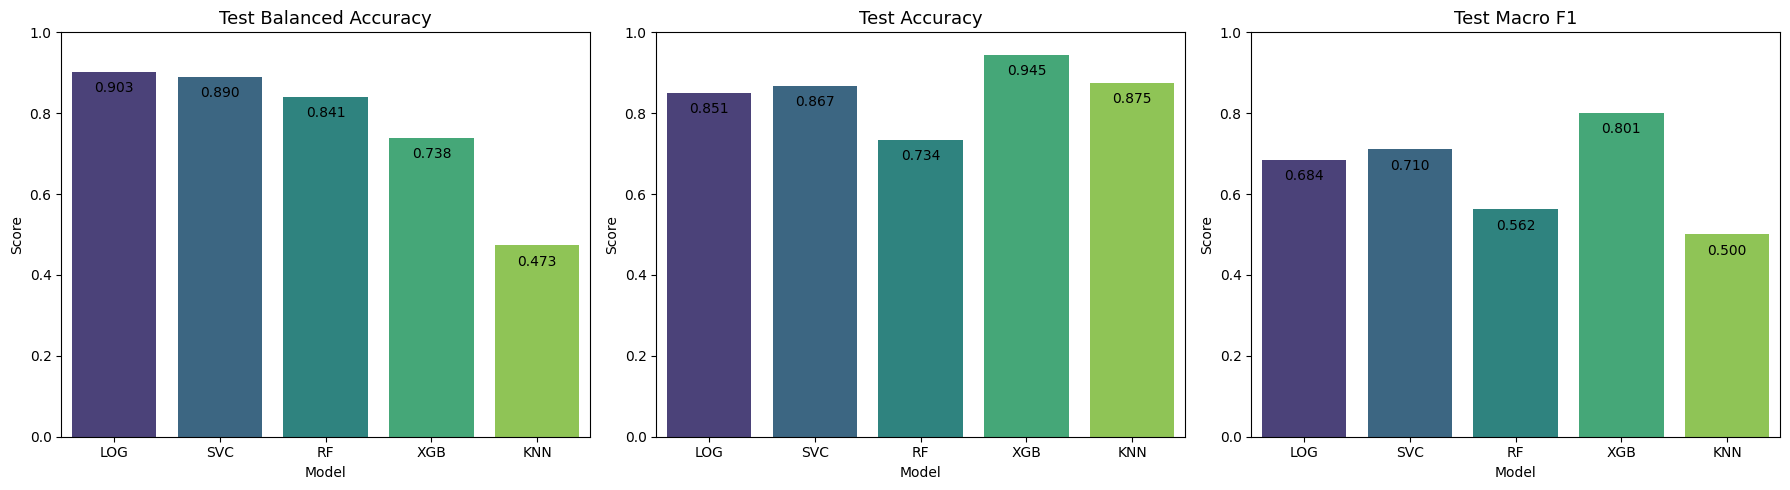

In [45]:
import matplotlib.pyplot as plt
import seaborn as sns

# Ensure correct sort order
results_df_cls = results_df_cls.reset_index(drop=True)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

metrics = [
    ("test_balanced_accuracy", "Test Balanced Accuracy"),
    ("test_accuracy", "Test Accuracy"),
    ("test_f1_macro", "Test Macro F1")
]

for ax, (col, title) in zip(axes, metrics):
    sns.barplot(
        data=results_df_cls,
        x="model",
        y=col,
        palette="viridis",
        ax=ax
    )

    ax.set_title(title, fontsize=13)
    ax.set_xlabel("Model")
    ax.set_ylabel("Score")
    ax.set_ylim(0, 1)

    # Add score above bars
    for i, row in results_df_cls.iterrows():
        ax.text(
            i, row[col] - 0.05,
            f"{row[col]:.3f}",
            ha="center", fontsize=10
        )

plt.tight_layout()
plt.show()



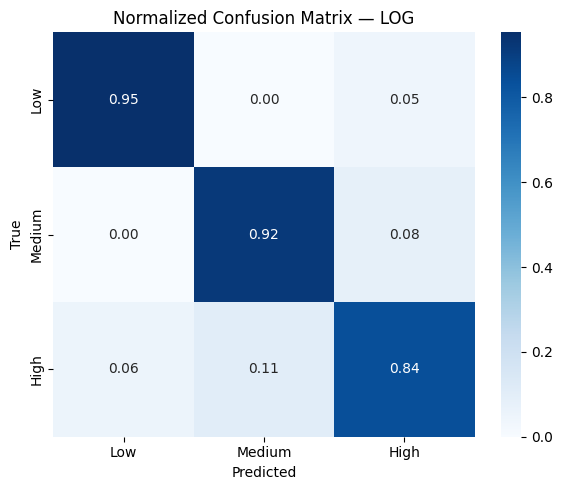


Classification report:

              precision    recall  f1-score   support

           0       0.30      0.95      0.46        43
           1       0.55      0.92      0.69       240
           2       0.98      0.84      0.91      1717

    accuracy                           0.85      2000
   macro avg       0.61      0.90      0.68      2000
weighted avg       0.92      0.85      0.87      2000



In [46]:
import matplotlib.pyplot as plt
import seaborn as sns

best_name = results_df_cls.iloc[0]["model"]
best_model = best_models_cls[best_name]

y_pred_best = best_model.predict(X_test)

cm = confusion_matrix(y_test, y_pred_best, labels=[0, 1, 2])
cm_norm = cm / cm.sum(axis=1, keepdims=True)

plt.figure(figsize=(6,5))
sns.heatmap(
    cm_norm,
    annot=True,
    fmt=".2f",
    xticklabels=["Low", "Medium", "High"],
    yticklabels=["Low", "Medium", "High"],
    cmap="Blues"
)
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title(f"Normalized Confusion Matrix — {best_name}")
plt.tight_layout()
plt.show()

print("\nClassification report:\n")
print(classification_report(y_test, y_pred_best))


**CLASSIFICATION WITH SMOTE AND UNDERSAMPLING**

Original target distribution (train):
risk_category
Medium    85.875
Low       11.975
High       2.150
Name: proportion, dtype: float64

Target distribution AFTER SMOTE + undersampling:
High      33.333333
Low       33.333333
Medium    33.333333
Name: proportion, dtype: float64


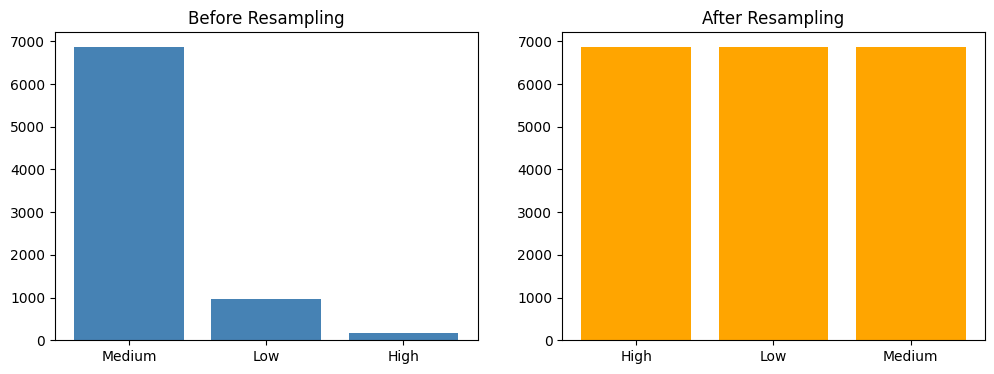


Training XGB...
Fitting 5 folds for each of 10 candidates, totalling 50 fits

Training RF...
Fitting 5 folds for each of 10 candidates, totalling 50 fits

Training LR...
Fitting 5 folds for each of 3 candidates, totalling 15 fits

Training SVM...
Fitting 5 folds for each of 6 candidates, totalling 30 fits

Training KNN...
Fitting 5 folds for each of 8 candidates, totalling 40 fits

===== FULL MODEL PERFORMANCE (CV + TEST) =====
  Model  F1_macro_CV  test_accuracy  test_balanced_accuracy  \
0   XGB     0.739011         0.9210                0.730148   
1    RF     0.682673         0.9060                0.697677   
3   SVM     0.713453         0.8830                0.763962   
2    LR     0.653294         0.8450                0.874939   
4   KNN     0.546142         0.7555                0.689367   

   test_precision_macro  test_recall_macro  test_f1_macro  
0              0.805029           0.730148       0.763530  
1              0.734757           0.697677       0.714379  
3       

In [47]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import OneHotEncoder, OrdinalEncoder, StandardScaler
from sklearn.compose import ColumnTransformer

from imblearn.pipeline import Pipeline   # imbalanced-learn pipeline
from imblearn.over_sampling import SMOTE
from imblearn.under_sampling import RandomUnderSampler

# ============================================================
# 1) TRAIN / TEST SPLIT + TARGET ENCODING
# ============================================================

target = "risk_category"

X = df_imputed.drop(columns=[target, "pollution_exposure_score"])
y = df_imputed[target]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42, stratify=y
)

# Target encoding
le = LabelEncoder()
y_train_enc = le.fit_transform(y_train)
y_test_enc  = le.transform(y_test)

print("Original target distribution (train):")
print(y_train.value_counts(normalize=True) * 100)

# ============================================================
# 2) PREPROCESSING (ordinal + nominal + numerical)
# ============================================================

ordinal_cols = {
    "green_space_access": ["Low", "Moderate", "High", "Missing"],
    "awareness_level": ["Low", "Medium", "High", "Missing"],
}

ordinal_categories = [ordinal_cols[c] for c in ordinal_cols.keys()]

nominal_cols = ["vehicle_ownership", "location_type", "work_location_type"]

numerical_cols = X_train.select_dtypes(include="number").columns.tolist()

preprocessor = ColumnTransformer(
    transformers=[
        ("ord", OrdinalEncoder(categories=ordinal_categories), list(ordinal_cols.keys())),
        ("nom", OneHotEncoder(handle_unknown="ignore"), nominal_cols),
        ("num", StandardScaler(), numerical_cols),
    ],
    remainder="drop"
)

# ============================================================
# 3) CORRECT SMOTE + UNDERSAMPLING (NO NESTED PIPELINE)
# ============================================================

smote = SMOTE(k_neighbors=5)
under = RandomUnderSampler()

# Apply preprocessing to X_train to inspect distribution AFTER resampling
X_train_transformed = preprocessor.fit_transform(X_train)
X_resampled, y_resampled = smote.fit_resample(X_train_transformed, y_train_enc)
X_resampled, y_resampled = under.fit_resample(X_resampled, y_resampled)

y_resampled_labels = le.inverse_transform(y_resampled)

print("\nTarget distribution AFTER SMOTE + undersampling:")
print(pd.Series(y_resampled_labels).value_counts(normalize=True) * 100)

# Plot before/after
before = y_train.value_counts()
after = pd.Series(y_resampled_labels).value_counts()

fig, ax = plt.subplots(1, 2, figsize=(12, 4))

ax[0].bar(before.index, before.values, color="steelblue")
ax[0].set_title("Before Resampling")

ax[1].bar(after.index, after.values, color="orange")
ax[1].set_title("After Resampling")

plt.show()

# ============================================================
# 4) PIPELINES FOR ALL MODELS (corrected)
# ============================================================

from xgboost import XGBClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier

def make_pipeline(model):
    return Pipeline([
        ("prep", preprocessor),
        ("smote", SMOTE(k_neighbors=5)),
        ("under", RandomUnderSampler()),
        ("model", model)
    ])

pipelines = {
    "XGB": make_pipeline(XGBClassifier(
        objective="multi:softprob",
        num_class=3,
        eval_metric="mlogloss",
        tree_method="hist",
        random_state=42
    )),
    "RF": make_pipeline(RandomForestClassifier()),
    "LR": make_pipeline(LogisticRegression(max_iter=5000, multi_class="multinomial")),
    "SVM": make_pipeline(SVC(probability=True)),
    "KNN": make_pipeline(KNeighborsClassifier())
}

# ============================================================
# 5) HYPERPARAMETER SEARCHES (correct)
# ============================================================

from sklearn.model_selection import RandomizedSearchCV

searches = {
    "XGB": RandomizedSearchCV(
        pipelines["XGB"],
        {
            "model__max_depth": [3, 5, 7],
            "model__learning_rate": [0.01, 0.05, 0.1],
            "model__subsample": [0.6, 0.8, 1.0],
            "model__colsample_bytree": [0.6, 0.8, 1.0]
        },
        n_iter=10, cv=5, scoring="f1_macro", verbose=2, n_jobs=-1
    ),

    "RF": RandomizedSearchCV(
        pipelines["RF"],
        {
            "model__n_estimators": [300, 500, 800],
            "model__max_depth": [None, 10, 20],
            "model__min_samples_split": [2, 5, 10],
        },
        n_iter=10, cv=5, scoring="f1_macro", verbose=2, n_jobs=-1
    ),

    "LR": RandomizedSearchCV(
        pipelines["LR"],
        {
            "model__C": [0.1, 1.0, 10.0],
        },
        n_iter=5, cv=5, scoring="f1_macro", verbose=2, n_jobs=-1
    ),

    "SVM": RandomizedSearchCV(
        pipelines["SVM"],
        {
            "model__C": [0.1, 1.0, 10.0],
            "model__gamma": ["scale", "auto"]
        },
        n_iter=6, cv=5, scoring="f1_macro", verbose=2, n_jobs=-1
    ),

    "KNN": RandomizedSearchCV(
        pipelines["KNN"],
        {
            "model__n_neighbors": [3, 5, 7, 9],
            "model__weights": ["uniform", "distance"]
        },
        n_iter=8, cv=5, scoring="f1_macro", verbose=2, n_jobs=-1
    )
}

# ============================================================
# 6) TRAIN ALL MODELS
# ============================================================

best_models = {}
cv_results = {}

for name, search in searches.items():
    print(f"\nTraining {name}...")
    search.fit(X_train, y_train_enc)
    best_models[name] = search.best_estimator_
    cv_results[name] = search.best_score_

# ============================================================
# 7) TEST MODELS ON HOLDOUT SET
# ============================================================

from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    precision_score,
    recall_score,
    f1_score
)

test_results = []

for name, model in best_models.items():
    y_pred = model.predict(X_test)

    test_results.append({
        "Model": name,
        "F1_macro_CV": cv_results[name],   # CV result

        # ---- Test metrics ----
        "test_accuracy": accuracy_score(y_test_enc, y_pred),
        "test_balanced_accuracy": balanced_accuracy_score(y_test_enc, y_pred),
        "test_precision_macro": precision_score(y_test_enc, y_pred, average="macro", zero_division=0),
        "test_recall_macro": recall_score(y_test_enc, y_pred, average="macro", zero_division=0),
        "test_f1_macro": f1_score(y_test_enc, y_pred, average="macro")
    })

results_df_cls = pd.DataFrame(test_results).sort_values("test_f1_macro", ascending=False)

print("\n===== FULL MODEL PERFORMANCE (CV + TEST) =====")
print(results_df_cls)





In [48]:
best_model_name = results_df_cls.sort_values(
    "test_balanced_accuracy", ascending=False
)["Model"].iloc[0]

best_model_cls = best_models[best_model_name]

print("Best model:", best_model_name)

Best model: LR


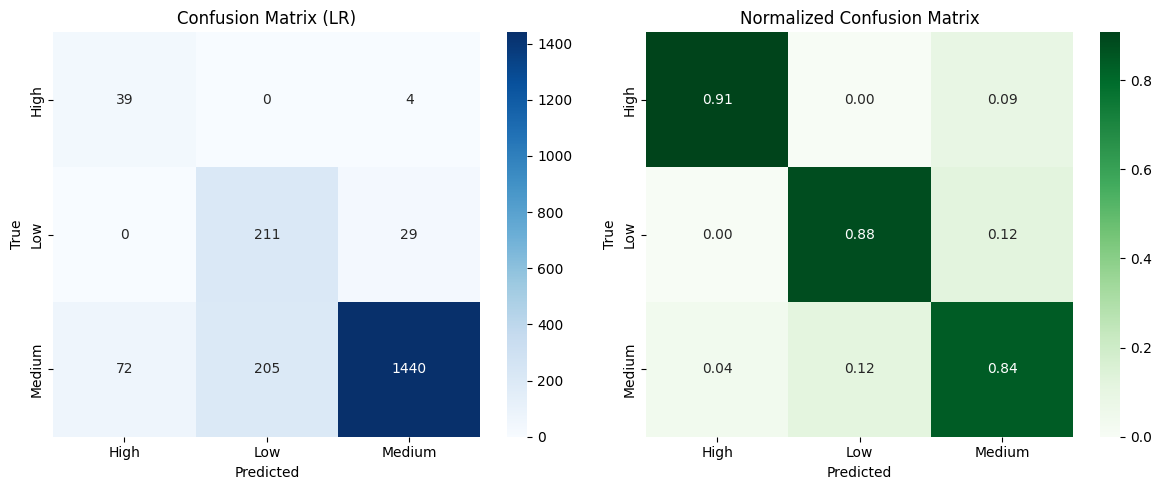


Classification Report:

              precision    recall  f1-score   support

        High       0.35      0.91      0.51        43
         Low       0.51      0.88      0.64       240
      Medium       0.98      0.84      0.90      1717

    accuracy                           0.84      2000
   macro avg       0.61      0.87      0.68      2000
weighted avg       0.91      0.84      0.86      2000



In [49]:
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns
import matplotlib.pyplot as plt

# Predict test set
y_pred = best_model_cls.predict(X_test)

# Labels (original category order)
class_labels = le.classes_

# Confusion matrix
cm = confusion_matrix(y_test_enc, y_pred)
cm_norm = confusion_matrix(y_test_enc, y_pred, normalize='true')

fig, ax = plt.subplots(1, 2, figsize=(12, 5))

sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", ax=ax[0], xticklabels=class_labels, yticklabels=class_labels)
ax[0].set_title(f"Confusion Matrix ({best_model_name})")
ax[0].set_xlabel("Predicted")
ax[0].set_ylabel("True")

sns.heatmap(cm_norm, annot=True, fmt=".2f", cmap="Greens", ax=ax[1], xticklabels=class_labels, yticklabels=class_labels)
ax[1].set_title("Normalized Confusion Matrix")
ax[1].set_xlabel("Predicted")
ax[1].set_ylabel("True")

plt.tight_layout()
plt.show()

print("\nClassification Report:\n")
print(classification_report(y_test_enc, y_pred, target_names=class_labels))


In [50]:
def get_feature_names(preprocessor):
    names = []

    # Ordinal
    ord_cols = list(ordinal_cols.keys())
    names.extend(ord_cols)

    # Nominal → OneHot categories
    ohe = preprocessor.named_transformers_["nom"]
    ohe_cols = ohe.get_feature_names_out(nominal_cols)
    names.extend(ohe_cols)

    # Numerical
    names.extend(numerical_cols)

    return names


feature_names = get_feature_names(best_model_cls.named_steps["prep"])


In [51]:
import numpy as np

model = best_model_cls.named_steps["model"]

try:
    importances = model.feature_importances_
except:
    print("Model does not provide feature importances.")
    importances = None

if importances is not None:
    fi_df = pd.DataFrame({
        "feature": feature_names,
        "importance": importances
    }).sort_values("importance", ascending=False)

    plt.figure(figsize=(10, 8))
    sns.barplot(data=fi_df.head(20), x="importance", y="feature", palette="viridis")
    plt.title(f"Top 20 Feature Importances ({best_model_name})")
    plt.tight_layout()
    plt.show()


Model does not provide feature importances.


Removed vehicle_ownership_missing → Balanced Acc: 0.6626
Removed daily_travel_time_missing → Balanced Acc: 0.6552
Removed years_in_location_missing → Balanced Acc: 0.6566
Removed work_location_type_missing → Balanced Acc: 0.6566
Removed nearby_industries_missing → Balanced Acc: 0.6544
Removed awareness_level_missing → Balanced Acc: 0.6419
Removed green_space_access_missing → Balanced Acc: 0.6433
Removed years_in_location → Balanced Acc: 0.6288
Removed noise_pollution_level → Balanced Acc: 0.6342
Removed awareness_level → Balanced Acc: 0.6070
Removed daily_travel_time → Balanced Acc: 0.5417
Removed home_air_quality → Balanced Acc: 0.4816
Removed green_space_access → Balanced Acc: 0.4689
Removed nearby_industries → Balanced Acc: 0.3333


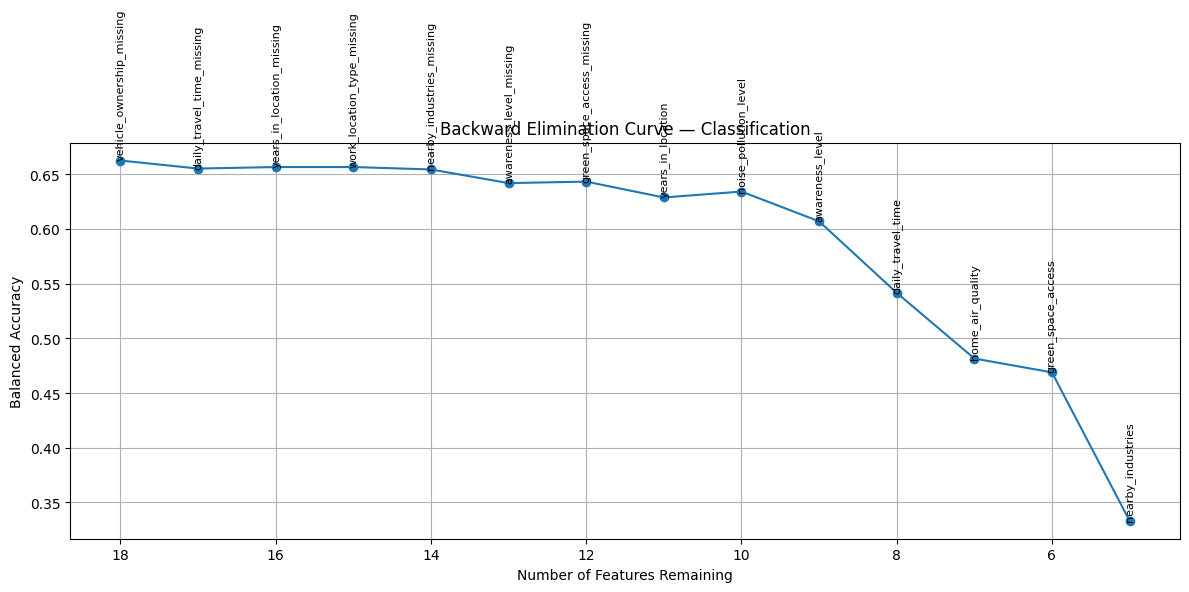

In [52]:
def map_back_to_original(feature_names):
    original_map = {}
    
    for f in feature_names:
        # OneHot columns
        for col in nominal_cols:
            if f.startswith(col + "_"):
                original_map[f] = col

        # Ordinals
        for col in ordinal_cols.keys():
            if f == col:
                original_map[f] = col

        # Numericals
        for col in numerical_cols:
            if f == col:
                original_map[f] = col

    return original_map

mapped = map_back_to_original(feature_names)

fi_original = (
    fi_df.assign(original=fi_df["feature"].map(mapped))
         .groupby("original")["importance"]
         .sum()
         .sort_values()
)

features_by_importance = list(fi_original.index)  # least → most important

from sklearn.metrics import f1_score, balanced_accuracy_score

results_elim = []
removed = []

model_cls = best_model_cls.named_steps["model"]

for f in features_by_importance:

    removed.append(f)

    # Remaining features
    keep = [c for c in X_train.columns if c not in removed]

    if len(keep) == 0:
        print("\nNo features left — stopping elimination.")
        break

    # Build correct subsets of column types
    ord_keep = [c for c in ordinal_cols.keys() if c in keep]
    nom_keep = [c for c in nominal_cols if c in keep]
    num_keep = [c for c in numerical_cols if c in keep]

    transformers = []

    if ord_keep:
        transformers.append(
            ("ord", OrdinalEncoder(categories=[ordinal_cols[c] for c in ord_keep]), ord_keep)
        )

    if nom_keep:
        transformers.append(
            ("nom", OneHotEncoder(handle_unknown="ignore"), nom_keep)
        )

    if num_keep:
        transformers.append(
            ("num", StandardScaler(), num_keep)
        )

    if not transformers:
        print("\n⚠ No transformers left — stopping elimination.")
        break

    sub_preprocessor = ColumnTransformer(
        transformers=transformers,
        remainder="drop"
    )

    # Build model without SMOTE/undersampling
    sub_pipe = Pipeline([
        ("prep", sub_preprocessor),
        ("model", model_cls.__class__(**model_cls.get_params()))
    ])

    # Train & evaluate
    sub_pipe.fit(X_train[keep], y_train_enc)
    y_pred_sub = sub_pipe.predict(X_test[keep])

    results_elim.append({
        "removed_feature": f,
        "remaining": len(keep),
        "balanced_accuracy": balanced_accuracy_score(y_test_enc, y_pred_sub),
        "f1_macro": f1_score(y_test_enc, y_pred_sub, average="macro")
    })

    print(f"Removed {f} → Balanced Acc: {results_elim[-1]['balanced_accuracy']:.4f}")

elim_df = pd.DataFrame(results_elim)

plt.figure(figsize=(12,6))
plt.plot(elim_df["remaining"], elim_df["balanced_accuracy"], marker="o")

for i, row in elim_df.iterrows():
    plt.text(
        row["remaining"],
        row["balanced_accuracy"],
        row["removed_feature"],
        fontsize=8,
        rotation=90,        # ← rotate label vertically
        va="bottom",        # vertical alignment
        ha="center"         # horizontal alignment
    )

plt.gca().invert_xaxis()
plt.xlabel("Number of Features Remaining")
plt.ylabel("Balanced Accuracy")
plt.title("Backward Elimination Curve — Classification")
plt.grid(True)
plt.tight_layout()
plt.show()


